In [1]:
%load_ext cuml.accel
# %run /workspace/alvin/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
%run /mnt/d/Users/Admin/Projects/dso/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
import os
import re
import copy
import random
from collections import defaultdict
from joblib import Parallel, delayed
from tqdm import tqdm
import pickle
import time

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from cuml.manifold import TSNE, UMAP

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, ConcatDataset, Subset, Dataset

import sys
sys.path.append("/mnt/d/Users/Admin/Projects/dso/learnable_polyphase_sampling/learn_poly_sampling")

from functools import partial
from layers import PolyphaseInvariantDown2D, LPS, get_logits_model
from models.resnet_custom import ResNet18Custom

In [2]:
get_logits = get_logits_model('LPSLogitLayers')
pooling_layer = partial(PolyphaseInvariantDown2D, component_selection=LPS, get_logits=get_logits)

extras_model = {
    'logits_channels': {"maxpool": 8, "layer2": 16, "layer3": 32, "layer4": 64},
    'conv1_stride': False,
    'maxpool_zpad': False,
    'swap_conv_pool': True,
    'inc_conv1_support': True,
    'apply_maxpool': True,
    'ret_prob': True,
    'forward_pool_method': 'LPS',
}

their_model = ResNet18Custom(
    input_shape=(3, 128, 128),
    num_classes=10,
    padding_mode='circular',
    pooling_layer=pooling_layer,
    extras_model=extras_model,
)
print(their_model)

[ResNet18Custom] self.maxpool_no_antialias: True
[ResNet18Custom] pooling_layer: functools.partial(<class 'layers.polydown.PolyphaseInvariantDown2D'>, component_selection=<class 'layers.polydown.LPS'>, get_logits=<class 'layers.lps_logit_layers.LPSLogitLayersV2'>)
ResNet18Custom(
  (core): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), bias=False, padding_mode=circular)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): Sequential(
      (0): PolyphaseInvariantDown2D(
        (component_selection): LPS(
          (get_logits): LPSLogitLayersV2(
            (conv1): Conv2d(64, 8, kernel_size=(3, 3), stride=(1, 1), padding=same, padding_mode=circular)
            (conv2): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=same, padding_mode=circular)
            (relu): ReLU()
          )
        )
      )
      (1): cpad(pad=[0, 1, 0, 1])
      (2): MaxPool2d

In [3]:
their_model = their_model.eval().double()
x = torch.randn(2, 3, 128, 128).double()
with torch.no_grad():
    y_orig = their_model.core(x)  # .core to bypass Lightning's forward()'s log_softmax, or use their_model(x) directly since it applies log_softmax too
    x_roll = torch.roll(x, shifts=(10, 10), dims=(-1, -2))
    y_roll = their_model.core(x_roll)
print(torch.norm(y_orig - y_roll).item())

6.8447748099657486e-15


In [4]:
def set_seed(seed=42):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # Uncomment only if you need 100% determinism and can handle errors
    # torch.use_deterministic_algorithms(True, warn_only=True)
    # os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    
    os.environ["PYTHONHASHSEED"] = str(seed)

def worker_init_fn(worker_id):
    """DataLoader worker init for reproducibility"""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [5]:
# workspace = "/workspace/alvin/SAR_ML"
workspace = "/mnt/d/Users/Admin/Projects/dso/SAR_ML"
data_workspace = os.path.join(workspace, "data/SAMPLE")

In [6]:
no_aug_synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

In [7]:
synth_paths = [s[0] for s in no_aug_synth_ds.samples]

synth_target_cache = {}
for path in tqdm(synth_paths):
    img = mat_file_loader(path)
    img = LogMapping(c=1000.0)(Magnitude()(img))
    T, S, _ = zhao_segmentation_v2(img)
    synth_target_cache[path] = (T).astype(np.uint8)

meas_paths = [s[0] for s in meas_ds.samples]

meas_target_cache = {}
for path in tqdm(meas_paths):
    img = mat_file_loader(path)
    img = LogMapping(c=1000.0)(Magnitude()(img))
    T, S, _ = zhao_segmentation_v2(img)
    meas_target_cache[path] = (T).astype(np.uint8)

100%|███████████████████████████████████████████████████████████████████████████████| 1345/1345 [01:03<00:00, 21.10it/s]


In [8]:
gaussian_seg_target_synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions=(".mat"),
    transform=transforms.Compose([
        Magnitude(),
        LogMapping(c=1000.0),
        MaskedAugmentation(augmentation=GaussianNoise(mu = 0, sigma = 0.3), fill=0, mask_cache=synth_target_cache),
        NumpyToTensor3Channel()
    ]),
    loader=mat_file_loader
)

seg_target_synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions=(".mat"),
    transform=transforms.Compose([
        Magnitude(),
        LogMapping(c=1000.0),
        MaskedAugmentation(augmentation=identity, fill=0, mask_cache=synth_target_cache),
        NumpyToTensor3Channel()
    ]),
    loader=mat_file_loader
)

seg_target_meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions=(".mat"),
    transform=transforms.Compose([
        Magnitude(),
        LogMapping(c=1000.0),
        MaskedAugmentation(augmentation=identity, fill=0, mask_cache=meas_target_cache),
        NumpyToTensor3Channel()
    ]),
    loader=mat_file_loader
)

In [9]:
train_ds = filter_by_elev(gaussian_seg_target_synth_ds, {14, 15, 16})
valid_ds = filter_by_elev(seg_target_meas_ds, {14, 15, 16})
test_ds = filter_by_elev(seg_target_meas_ds, {17})

ds_dict = {"train" : train_ds, "val": valid_ds, "test": test_ds}
dataset_sizes = {"train" : len(train_ds), "val": len(valid_ds), "test": len(test_ds)}

In [11]:
seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]
 
train_loss = []
val_loss = []
train_acc = []
val_acc = []
 
for i, seed in enumerate(seed_lst):
    
    start = time.perf_counter()
    
    print(f"Training Run {i}: seed {seed}")
    set_seed(seed)
 
    dataloaders = {
        "train": DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)),
        "val": DataLoader(valid_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)),
        "test": DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed))
    }
    get_logits = get_logits_model('LPSLogitLayers')
    pooling_layer = partial(PolyphaseInvariantDown2D, component_selection=LPS, get_logits=get_logits)
    extras_model = {
        'logits_channels': {"maxpool": 8, "layer2": 16, "layer3": 32, "layer4": 64},
        'conv1_stride': False,
        'maxpool_zpad': False,
        'swap_conv_pool': True,
        'inc_conv1_support': True,
        'apply_maxpool': True,
        'ret_prob': True,
        'forward_pool_method': 'LPS',
    }
    
    model = ResNet18Custom(
        input_shape=(3, 128, 128),
        num_classes=len(train_ds.class_to_idx),
        padding_mode='circular',
        pooling_layer=pooling_layer,
        extras_model=extras_model,
    )
 
    # Define the loss function and optimizer
    criterion = nn.NLLLoss()

    net_pars, pool_pars = [], []
    for n, p in model.named_parameters():
        if "component_selection" in n and p.requires_grad:
            pool_pars.append(p)
        elif p.requires_grad:
            net_pars.append(p)
            
    optimizer = optim.AdamW([
        {"params": net_pars, "weight_decay": 2e-4},
        {"params": pool_pars, "weight_decay": 0},
    ], lr=3e-4)
    
    scheduler = CosineAnnealingLR(optimizer, T_max=200, eta_min=3e-7)
    
    # move model to GPU
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
 
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }
 
    # Training loop
    num_epochs = 200
    for epoch in range(num_epochs):
        print(f"Epoch {epoch}")
        if epoch == 0:
            print(f"First layer mean: {model.core.conv1.weight.data.mean():.6f}")
        for phase in ["train", "val"]:
            if phase == "train":
                model.train()
            else:
                model.eval()
 
            running_loss = 0.0
            running_corrects = 0
 
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
 
                optimizer.zero_grad()
 
                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
 
                    if phase == "train":
                        loss.backward()
                        optimizer.step()
 
                running_loss += loss.item() * inputs.size(0)
                running_corrects += (preds == labels).sum().item()
 
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects / dataset_sizes[phase]
 
            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc)
 
            print(f"{phase} Loss: {epoch_loss:.10f} Acc: {epoch_acc:.10f}")
 
        scheduler.step()
        print(f"Epoch {epoch} LR: {scheduler.get_last_lr()[0]:.10f}")
 
    print("Training complete!")
 
    train_loss.append(history["train_loss"])
    val_loss.append(history["val_loss"])
    train_acc.append(history["train_acc"])
    val_acc.append(history["val_acc"])
 
    torch.save(model.state_dict(), os.path.join(workspace, f"weights/SSR/Extras/LPD/target_only/gaussian/rn18_seed{seed}_b16_theirmodel.pth"))
    end = time.perf_counter()
    elapsed = end - start
    print(f"Training time for Seed {seed}: {elapsed:.2f}s")
 
train_loss = np.array(train_loss)
val_loss = np.array(val_loss)
train_acc = np.array(train_acc)
val_acc = np.array(val_acc)

Training Run 0: seed 10
[ResNet18Custom] self.maxpool_no_antialias: True
[ResNet18Custom] pooling_layer: functools.partial(<class 'layers.polydown.PolyphaseInvariantDown2D'>, component_selection=<class 'layers.polydown.LPS'>, get_logits=<class 'layers.lps_logit_layers.LPSLogitLayersV2'>)
Epoch 0
First layer mean: 0.000035
train Loss: 1.6899665428 Acc: 0.3734491315
val Loss: 10.1101628613 Acc: 0.1439205955
Epoch 0 LR: 0.0002999815
Epoch 1
train Loss: 1.0793234698 Acc: 0.5806451613
val Loss: 2.7979844551 Acc: 0.2258064516
Epoch 1 LR: 0.0002999261
Epoch 2
train Loss: 0.7301923775 Acc: 0.7295285360
val Loss: 7.1711237629 Acc: 0.1290322581
Epoch 2 LR: 0.0002998336
Epoch 3
train Loss: 0.5788610224 Acc: 0.7952853598
val Loss: 2.7869329657 Acc: 0.2791563275
Epoch 3 LR: 0.0002997043
Epoch 4
train Loss: 0.4215260398 Acc: 0.8548387097
val Loss: 1.9620651944 Acc: 0.4553349876
Epoch 4 LR: 0.0002995381
Epoch 5
train Loss: 0.4120264590 Acc: 0.8535980149
val Loss: 5.1386967529 Acc: 0.1898263027
Epoch 

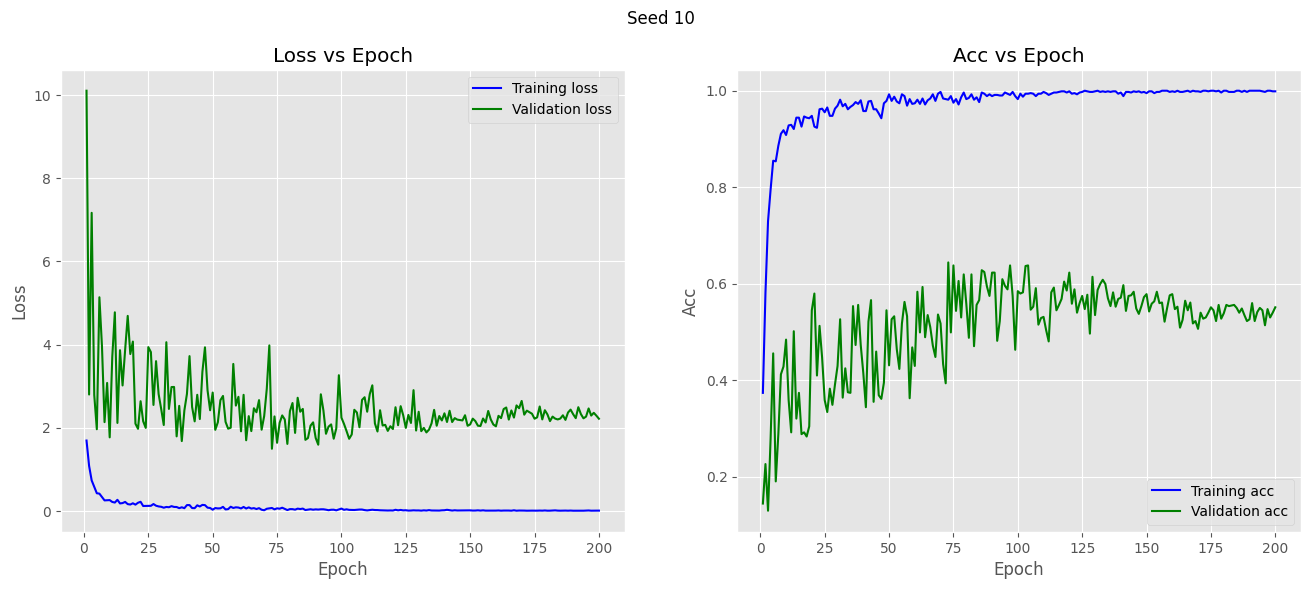

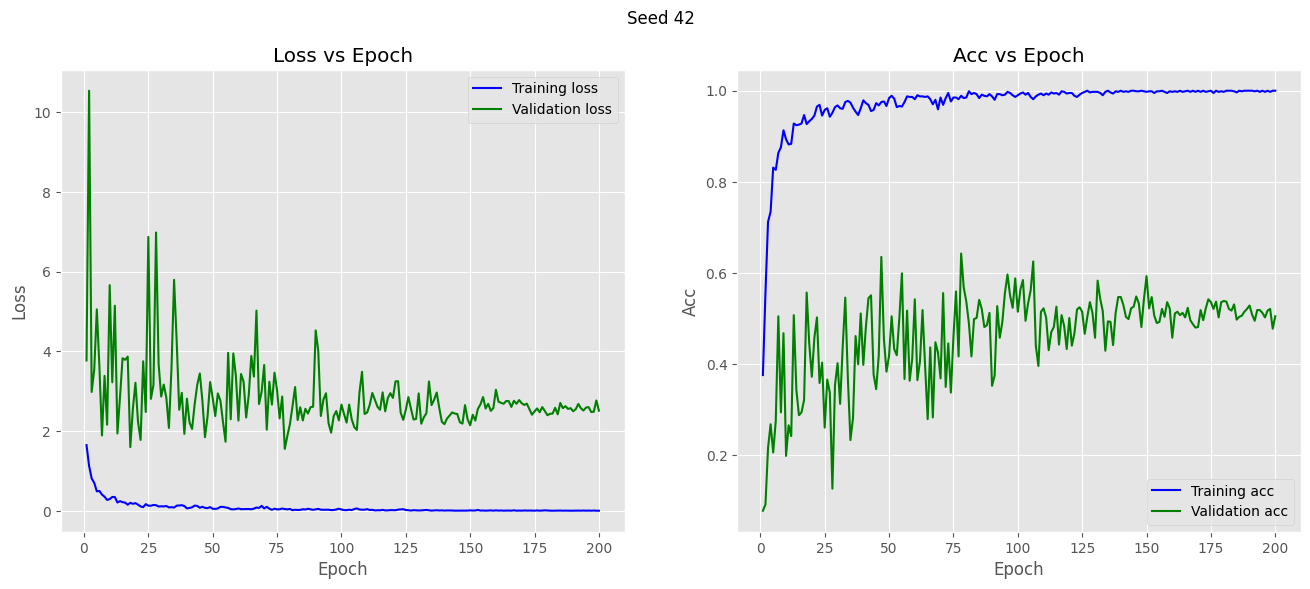

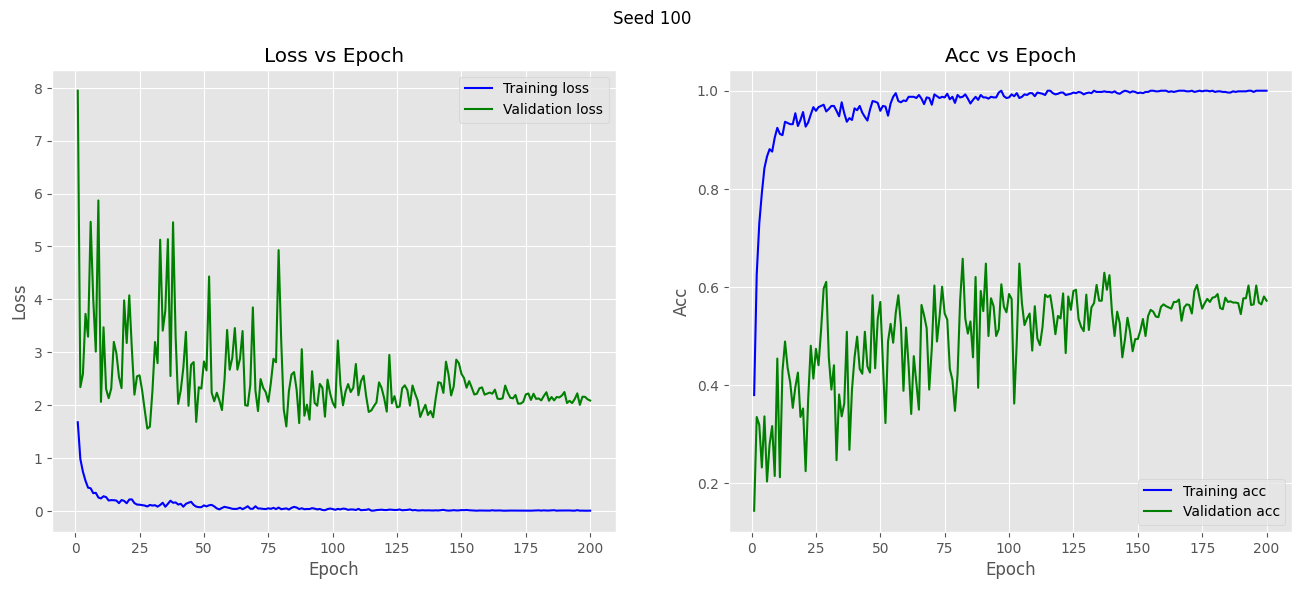

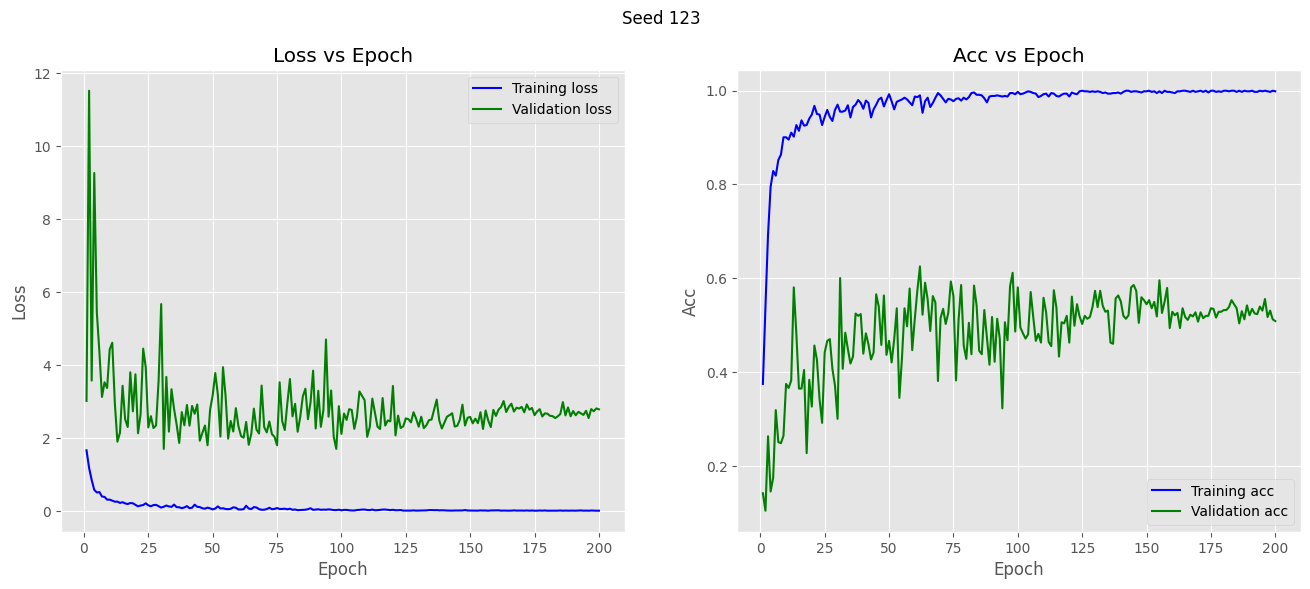

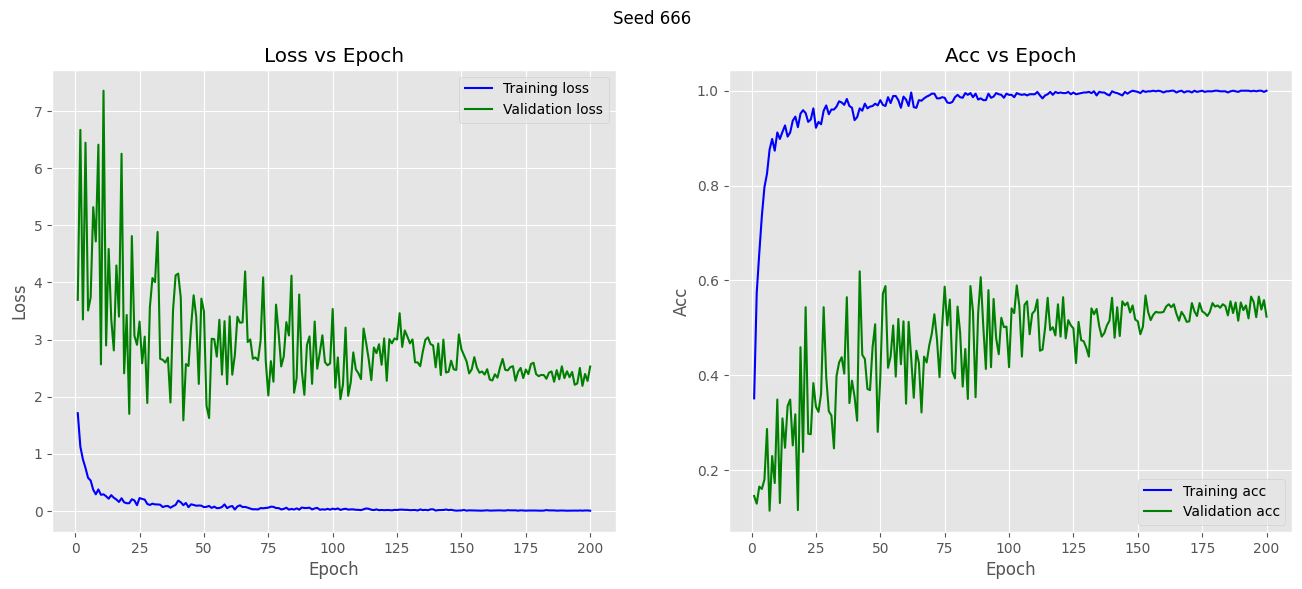

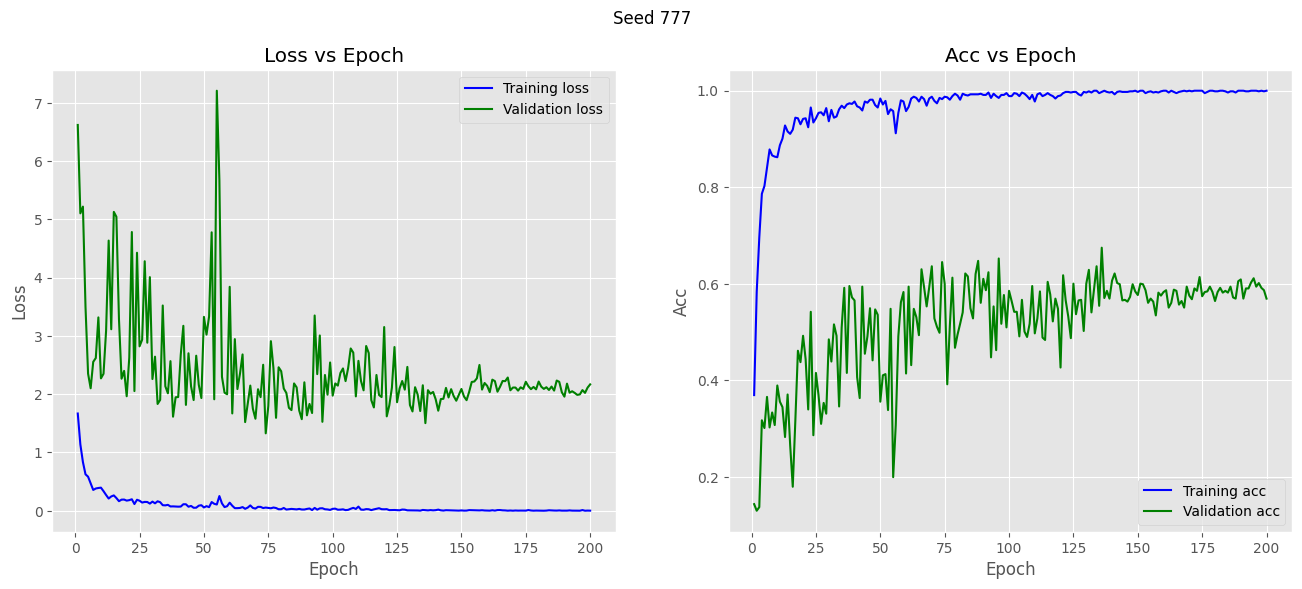

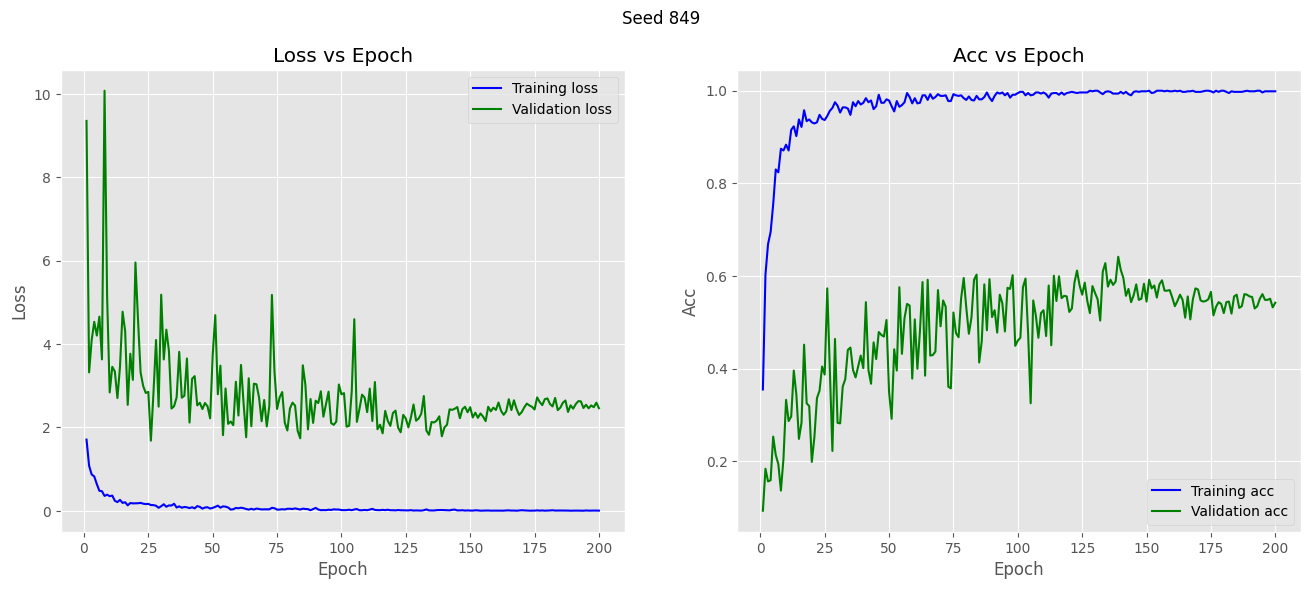

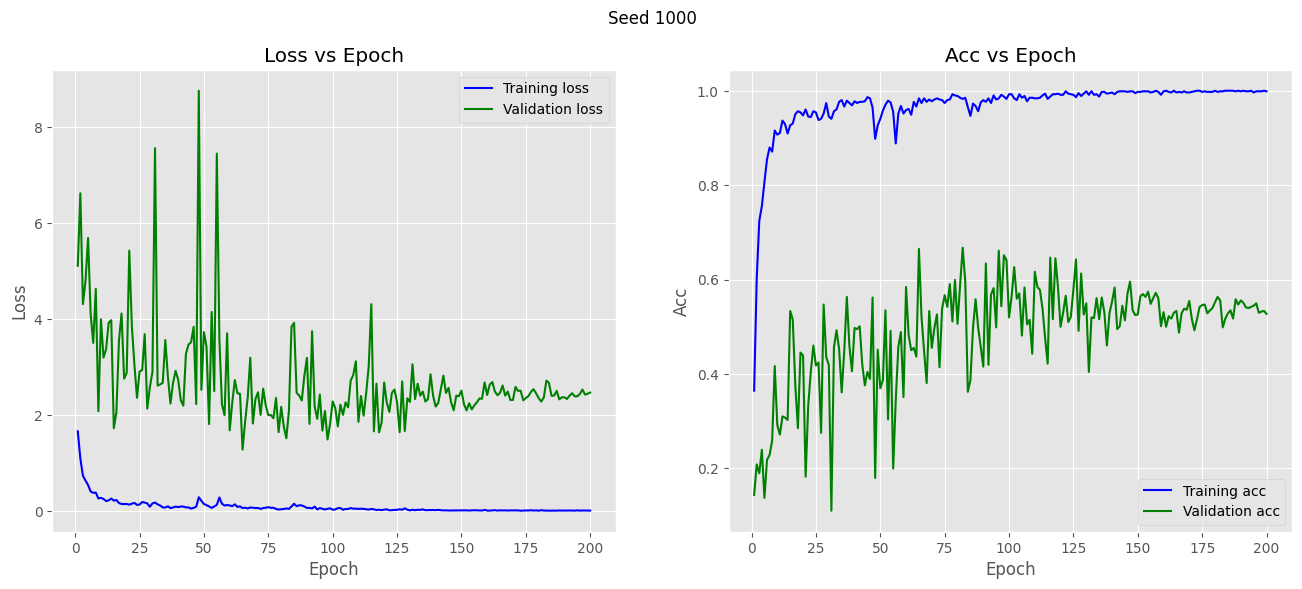

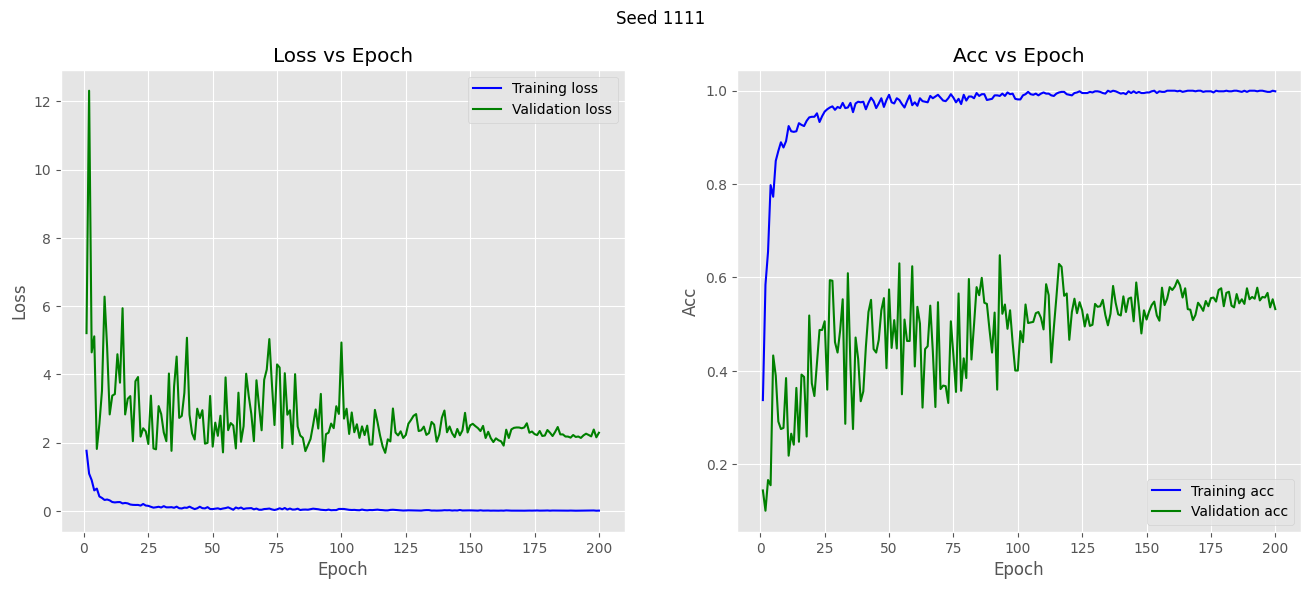

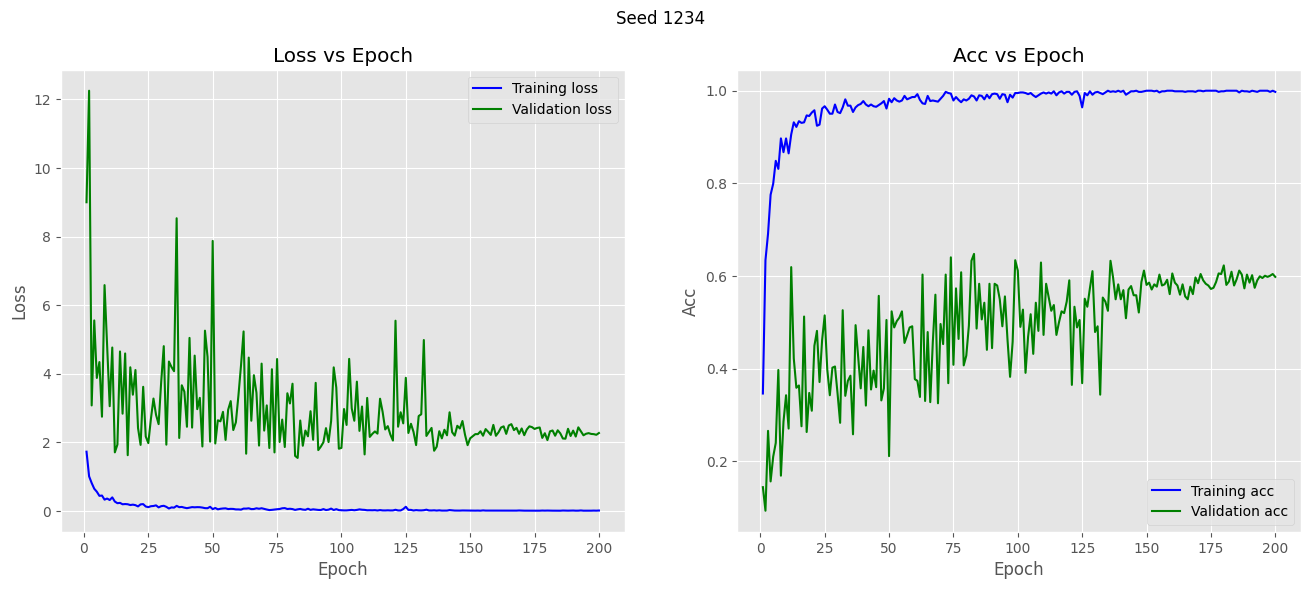

In [12]:
row, col = train_loss.shape

for i, seed in enumerate(seed_lst):
    
    with plt.style.context("ggplot"):
        fig = plt.figure(figsize = (16, 6))
    
        ax0 = fig.add_subplot(1, 2, 1)
        ax0.plot(np.arange(1, num_epochs+1), train_loss[i, :], label = "Training loss", c = "blue")
        ax0.plot(np.arange(1, num_epochs+1), val_loss[i, :], label = "Validation loss", c = "green")
        ax0.set_title("Loss vs Epoch")
        ax0.set_xlabel("Epoch")
        ax0.set_ylabel("Loss")
        ax0.legend()
        ax0.grid(True)
        
        ax1 = fig.add_subplot(1, 2, 2)
        ax1.plot(np.arange(1, num_epochs+1), train_acc[i, :], label = "Training acc", c = "blue")
        ax1.plot(np.arange(1, num_epochs+1), val_acc[i, :], label = "Validation acc", c = "green")
        ax1.set_title("Acc vs Epoch")
        ax1.set_xlabel("Epoch")
        ax1.set_ylabel("Acc")
        ax1.legend()
        ax1.grid(True)

        fig.suptitle(f"Seed {seed}")
        plt.show()

In [10]:
seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for i, seed in enumerate(seed_lst):
    print(f"Evaluating Run {i}: Seed {seed}")
    get_logits = get_logits_model('LPSLogitLayers')
    pooling_layer = partial(PolyphaseInvariantDown2D, component_selection=LPS, get_logits=get_logits)
    extras_model = {
        'logits_channels': {"maxpool": 8, "layer2": 16, "layer3": 32, "layer4": 64},
        'conv1_stride': False,
        'maxpool_zpad': False,
        'swap_conv_pool': True,
        'inc_conv1_support': True,
        'apply_maxpool': True,
        'ret_prob': True,
        'forward_pool_method': 'LPS',
    }
    
    new_model = ResNet18Custom(
        input_shape=(3, 128, 128),
        num_classes=len(train_ds.class_to_idx),
        padding_mode='circular',
        pooling_layer=pooling_layer,
        extras_model=extras_model,
    )
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Extras/LPD/target_only/gaussian/rn18_seed{seed}_b16_theirmodel.pth"),
        map_location=device
    ))
    
    new_model = new_model.to(device)
    new_model.eval()

    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=8, pin_memory = True, persistent_workers=True):
            inputs = inputs.to(device)
            labels = labels.to(device)
    
            outputs = new_model(inputs)
            _, preds = torch.max(outputs, 1)
    
            correct += torch.sum(preds == labels).item()
            total += labels.size(0)
    
    test_acc = correct / total
    print(f"Test Accuracy: {100*test_acc:.4f}")
    test_acc_lst.append(test_acc)

test_acc_arr = np.array(test_acc_lst)
print(f"Min: {test_acc_arr.min() * 100:.4f}")
print(f"Max: {test_acc_arr.max() * 100:.4f}")
print(f"Avg, Std: {test_acc_arr.mean() * 100:.4f}, {test_acc_arr.std() * 100:.4f}")

Evaluating Run 0: Seed 10
[ResNet18Custom] self.maxpool_no_antialias: True
[ResNet18Custom] pooling_layer: functools.partial(<class 'layers.polydown.PolyphaseInvariantDown2D'>, component_selection=<class 'layers.polydown.LPS'>, get_logits=<class 'layers.lps_logit_layers.LPSLogitLayersV2'>)
Test Accuracy: 58.8126
Evaluating Run 1: Seed 42
[ResNet18Custom] self.maxpool_no_antialias: True
[ResNet18Custom] pooling_layer: functools.partial(<class 'layers.polydown.PolyphaseInvariantDown2D'>, component_selection=<class 'layers.polydown.LPS'>, get_logits=<class 'layers.lps_logit_layers.LPSLogitLayersV2'>)
Test Accuracy: 59.7403
Evaluating Run 2: Seed 100
[ResNet18Custom] self.maxpool_no_antialias: True
[ResNet18Custom] pooling_layer: functools.partial(<class 'layers.polydown.PolyphaseInvariantDown2D'>, component_selection=<class 'layers.polydown.LPS'>, get_logits=<class 'layers.lps_logit_layers.LPSLogitLayersV2'>)
Test Accuracy: 63.2653
Evaluating Run 3: Seed 123
[ResNet18Custom] self.maxpool_

[ResNet18Custom] self.maxpool_no_antialias: True
[ResNet18Custom] pooling_layer: functools.partial(<class 'layers.polydown.PolyphaseInvariantDown2D'>, component_selection=<class 'layers.polydown.LPS'>, get_logits=<class 'layers.lps_logit_layers.LPSLogitLayersV2'>)


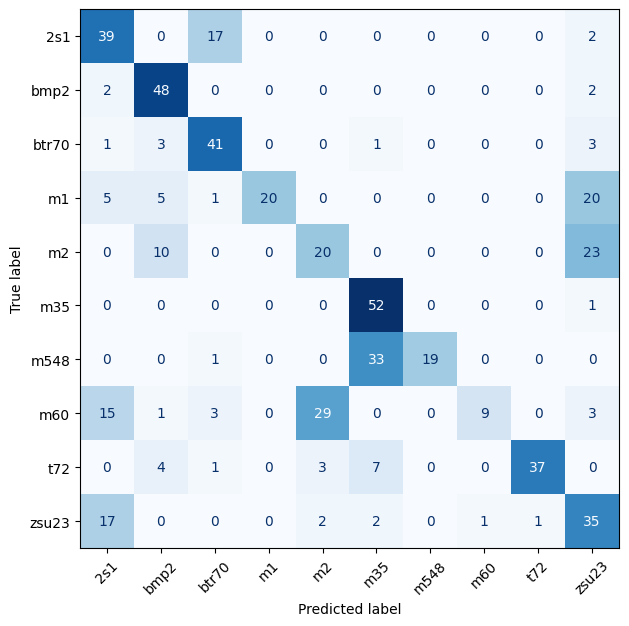

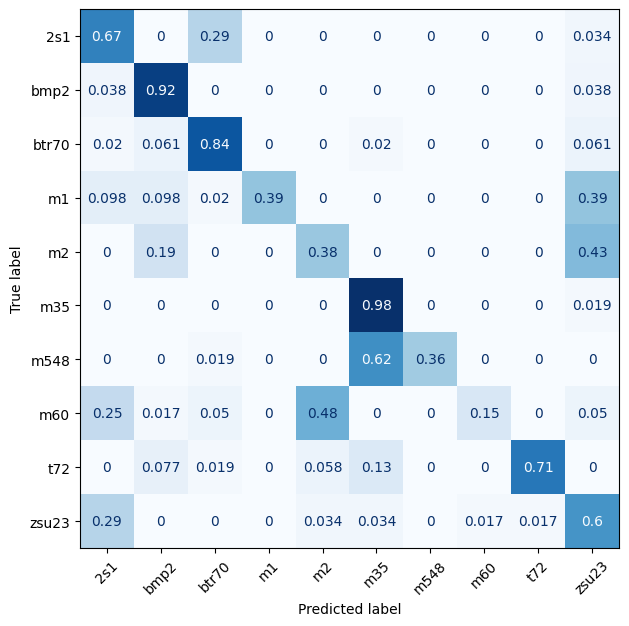

In [11]:
test_dataloader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4)

seed = 666
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

get_logits = get_logits_model('LPSLogitLayers')
pooling_layer = partial(PolyphaseInvariantDown2D, component_selection=LPS, get_logits=get_logits)
extras_model = {
    'logits_channels': {"maxpool": 8, "layer2": 16, "layer3": 32, "layer4": 64},
    'conv1_stride': False,
    'maxpool_zpad': False,
    'swap_conv_pool': True,
    'inc_conv1_support': True,
    'apply_maxpool': True,
    'ret_prob': True,
    'forward_pool_method': 'LPS',
}

new_model = ResNet18Custom(
    input_shape=(3, 128, 128),
    num_classes=len(train_ds.class_to_idx),
    padding_mode='circular',
    pooling_layer=pooling_layer,
    extras_model=extras_model,
)
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Extras/LPD/target_only/gaussian/rn18_seed{seed}_b16_theirmodel.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

n_test = len(test_ds)
labels_tensor = torch.zeros(n_test, dtype=torch.long, device=device)
preds_tensor = torch.zeros(n_test, dtype=torch.long, device=device)

idx = 0
with torch.no_grad():
    for inputs, labels in test_dataloader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = new_model(inputs)
        _, preds = torch.max(outputs, 1)

        bs = inputs.size(0)
        labels_tensor[idx:idx+bs] = labels
        preds_tensor[idx:idx+bs] = preds
        idx += bs

_labels_all = labels_tensor.cpu().numpy()
_preds_all = preds_tensor.cpu().numpy()

cm = confusion_matrix(_labels_all, _preds_all)
cm_cpu = cp.asnumpy(cm)
disp = ConfusionMatrixDisplay(cm_cpu, display_labels=list(test_ds.class_to_idx.keys()))
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.tick_params(axis='x', rotation=45)
plt.show()

cm_norm = confusion_matrix(_labels_all, _preds_all, normalize='true')
cm_norm_cpu = cp.asnumpy(cm_norm)
disp = ConfusionMatrixDisplay(cm_norm_cpu, display_labels=list(test_ds.class_to_idx.keys()))
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.tick_params(axis='x', rotation=45)
plt.show()

In [13]:
shifted_down_lst = [
    DatasetFolderWithPath(
        os.path.join(data_workspace, "mat_files/real"),
        extensions=(".mat"),
        transform=transforms.Compose([
            Magnitude(),
            LogMapping(c=1000.0),
            MaskedAugmentation(augmentation=identity, fill=0, mask_cache=meas_target_cache),
            CircularShift(shift_pixels = k, axis = -2),
            NumpyToTensor3Channel()
        ]),
        loader=mat_file_loader
    ) 
    for k in range(5, 25+5, 5)
]

shifted_up_lst = [
    DatasetFolderWithPath(
        os.path.join(data_workspace, "mat_files/real"),
        extensions=(".mat"),
        transform=transforms.Compose([
            Magnitude(),
            LogMapping(c=1000.0),
            MaskedAugmentation(augmentation=identity, fill=0, mask_cache=meas_target_cache),
            CircularShift(shift_pixels = -k, axis = -2),
            NumpyToTensor3Channel()
        ]),
        loader=mat_file_loader
    )
    for k in range(5, 35+5, 5)
]

shifted_left_lst = [
    DatasetFolderWithPath(
        os.path.join(data_workspace, "mat_files/real"),
        extensions=(".mat"),
        transform=transforms.Compose([
            Magnitude(),
            LogMapping(c=1000.0),
            MaskedAugmentation(augmentation=identity, fill=0, mask_cache=meas_target_cache),
            CircularShift(shift_pixels = -k, axis = -1),
            NumpyToTensor3Channel()
        ]),
        loader=mat_file_loader
    )
    for k in range(5, 15+5, 5)
]

shifted_right_lst = [
    DatasetFolderWithPath(
        os.path.join(data_workspace, "mat_files/real"),
        extensions=(".mat"),
        transform=transforms.Compose([
            Magnitude(),
            LogMapping(c=1000.0),
            MaskedAugmentation(augmentation=identity, fill=0, mask_cache=meas_target_cache),
            CircularShift(shift_pixels = k, axis = -1),
            NumpyToTensor3Channel()
        ]),
        loader=mat_file_loader
    )
    for k in range(5, 35+5, 5)
]

shifted_down_17_lst = [filter_by_elev(ds, {17}) for ds in shifted_down_lst]
shifted_up_17_lst = [filter_by_elev(ds, {17}) for ds in shifted_up_lst]
shifted_left_17_lst = [filter_by_elev(ds, {17}) for ds in shifted_left_lst]
shifted_right_17_lst = [filter_by_elev(ds, {17}) for ds in shifted_right_lst]

shifted_datasets_17 = {
    "shifted down": (shifted_down_17_lst, [5, 10, 15, 20, 25]),
    "shifted up": (shifted_up_17_lst, [5, 10, 15, 20, 25, 30, 35]),
    "shifted left": (shifted_left_17_lst, [5, 10, 15]),
    "shifted right": (shifted_right_17_lst, [5, 10, 15, 20, 25, 30, 35])
}

In [14]:
seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    
for i, seed in enumerate(seed_lst):
    print(f"Evaluating Run {i}: Seed {seed}")
    get_logits = get_logits_model('LPSLogitLayers')
    pooling_layer = partial(PolyphaseInvariantDown2D, component_selection=LPS, get_logits=get_logits)
    extras_model = {
        'logits_channels': {"maxpool": 8, "layer2": 16, "layer3": 32, "layer4": 64},
        'conv1_stride': False,
        'maxpool_zpad': False,
        'swap_conv_pool': True,
        'inc_conv1_support': True,
        'apply_maxpool': True,
        'ret_prob': True,
        'forward_pool_method': 'LPS',
    }
    
    new_model = ResNet18Custom(
        input_shape=(3, 128, 128),
        num_classes=len(train_ds.class_to_idx),
        padding_mode='circular',
        pooling_layer=pooling_layer,
        extras_model=extras_model,
    )
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Extras/LPD/target_only/gaussian/rn18_seed{seed}_b16_theirmodel.pth"),
        map_location=device
    ))
    
    new_model = new_model.to(device)
    new_model.eval()
        
    for direction, (dataset_lst, units) in shifted_datasets_17.items():
        print(f"Evaluating {direction} datasets")

        for k, ds in enumerate(dataset_lst):
            print(f"{units[k]} units")

            correct = 0
            total = 0
            
            with torch.no_grad():
                for inputs, labels in DataLoader(ds, batch_size=32, shuffle=False, num_workers=8, pin_memory = True, persistent_workers=True):
                    inputs = inputs.to(device)
                    labels = labels.to(device)
            
                    outputs = new_model(inputs)
                    _, preds = torch.max(outputs, 1)
            
                    correct += torch.sum(preds == labels).item()
                    total += labels.size(0)
            test_acc = correct / total
            print(f"Test Accuracy: {100*test_acc:.4f}")
        print("\n")

Evaluating Run 0: Seed 10
[ResNet18Custom] self.maxpool_no_antialias: True
[ResNet18Custom] pooling_layer: functools.partial(<class 'layers.polydown.PolyphaseInvariantDown2D'>, component_selection=<class 'layers.polydown.LPS'>, get_logits=<class 'layers.lps_logit_layers.LPSLogitLayersV2'>)
Evaluating shifted down datasets
5 units
Test Accuracy: 58.8126
10 units
Test Accuracy: 58.8126
15 units
Test Accuracy: 58.8126
20 units
Test Accuracy: 58.8126
25 units
Test Accuracy: 58.8126


Evaluating shifted up datasets
5 units
Test Accuracy: 58.8126
10 units
Test Accuracy: 58.8126
15 units
Test Accuracy: 58.8126
20 units
Test Accuracy: 58.8126
25 units
Test Accuracy: 58.8126
30 units
Test Accuracy: 58.8126
35 units
Test Accuracy: 58.8126


Evaluating shifted left datasets
5 units
Test Accuracy: 58.8126
10 units
Test Accuracy: 58.8126
15 units
Test Accuracy: 58.8126


Evaluating shifted right datasets
5 units
Test Accuracy: 58.8126
10 units
Test Accuracy: 58.8126
15 units
Test Accuracy: 58.8126


[ResNet18Custom] self.maxpool_no_antialias: True
[ResNet18Custom] pooling_layer: functools.partial(<class 'layers.polydown.PolyphaseInvariantDown2D'>, component_selection=<class 'layers.polydown.LPS'>, get_logits=<class 'layers.lps_logit_layers.LPSLogitLayersV2'>)
Evaluating shifted down of 5 units


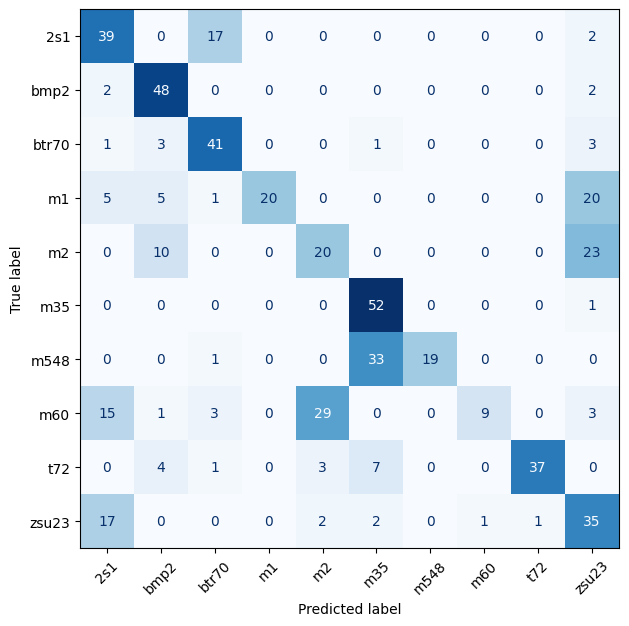

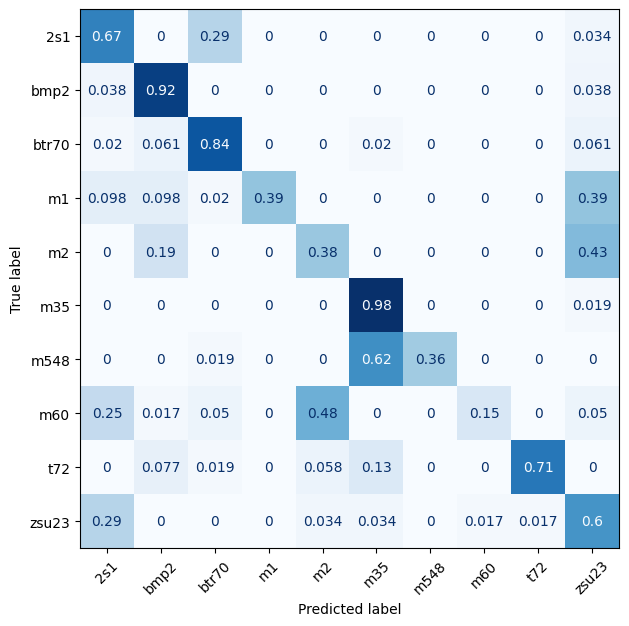

Evaluating shifted down of 10 units


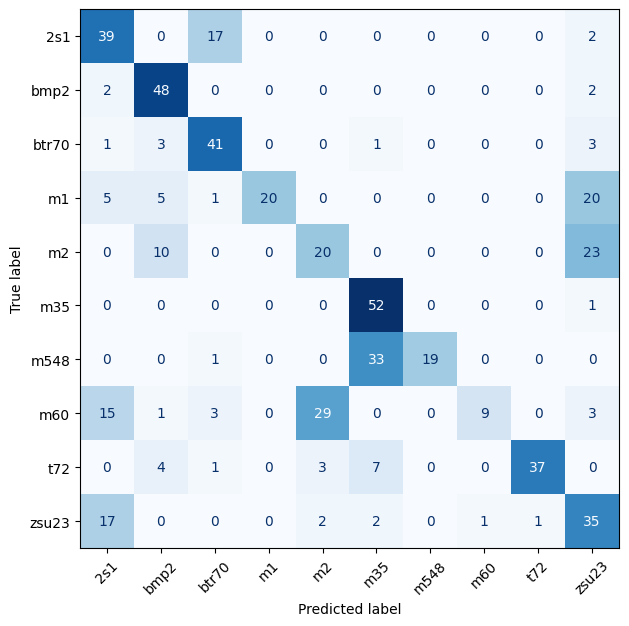

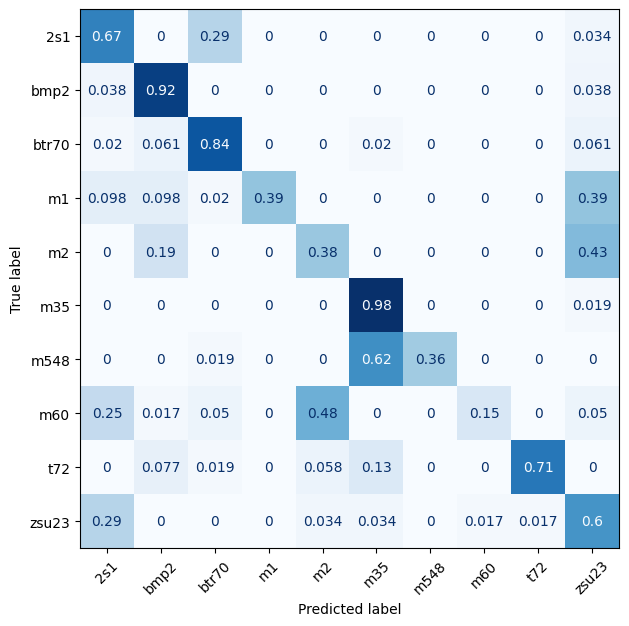

Evaluating shifted down of 15 units


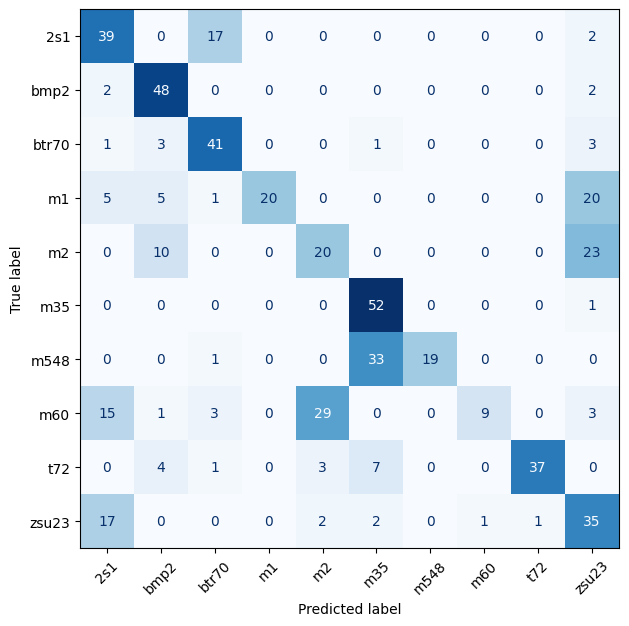

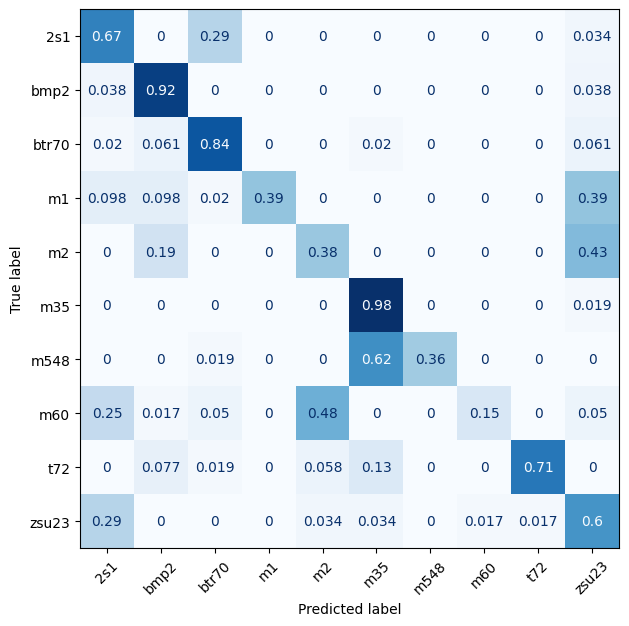

Evaluating shifted down of 20 units


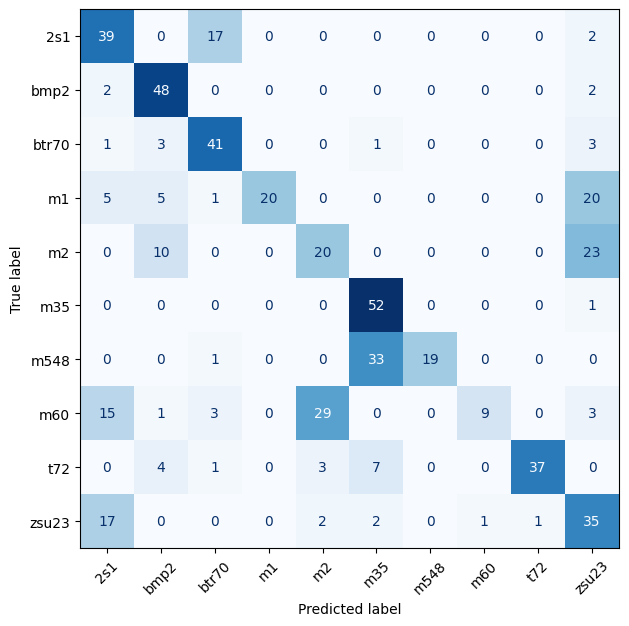

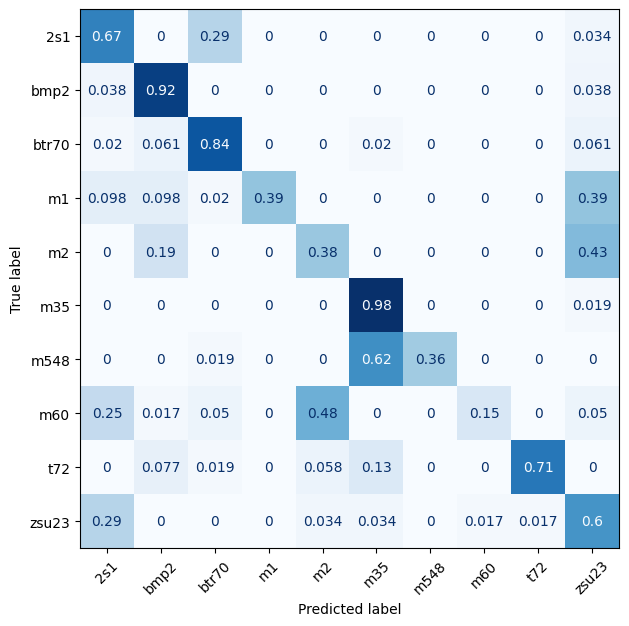

Evaluating shifted down of 25 units


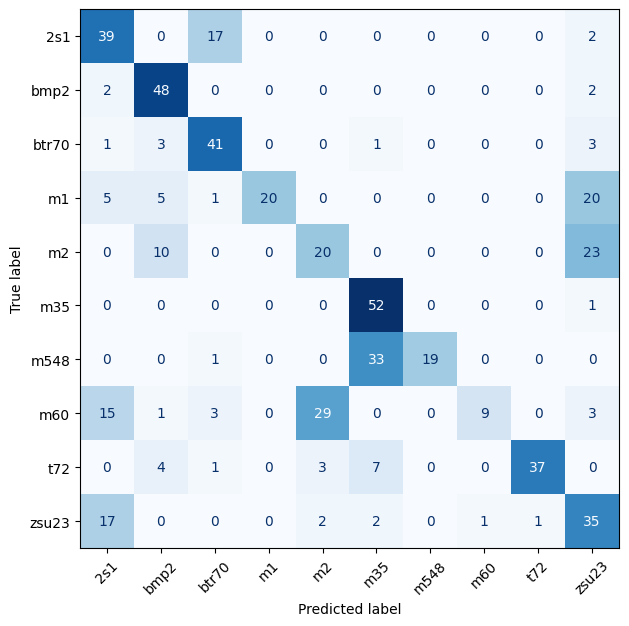

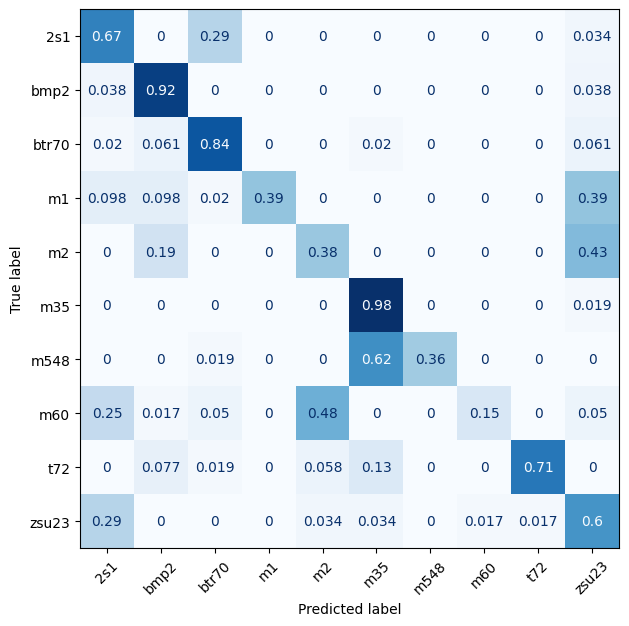

Evaluating shifted up of 5 units


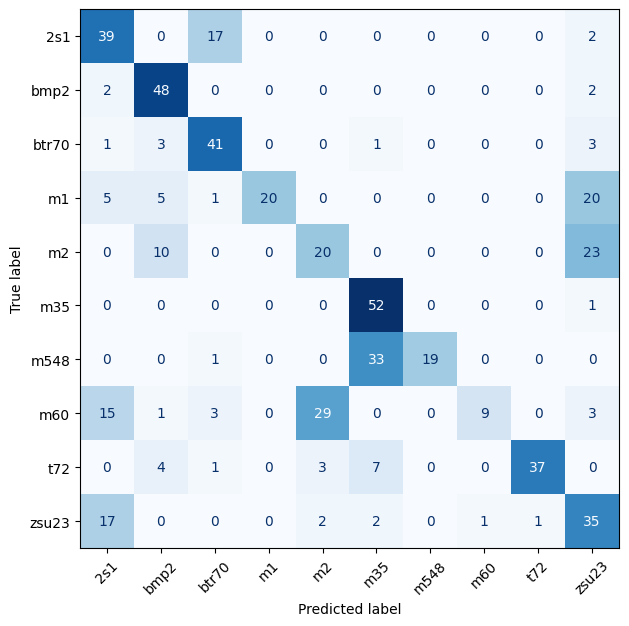

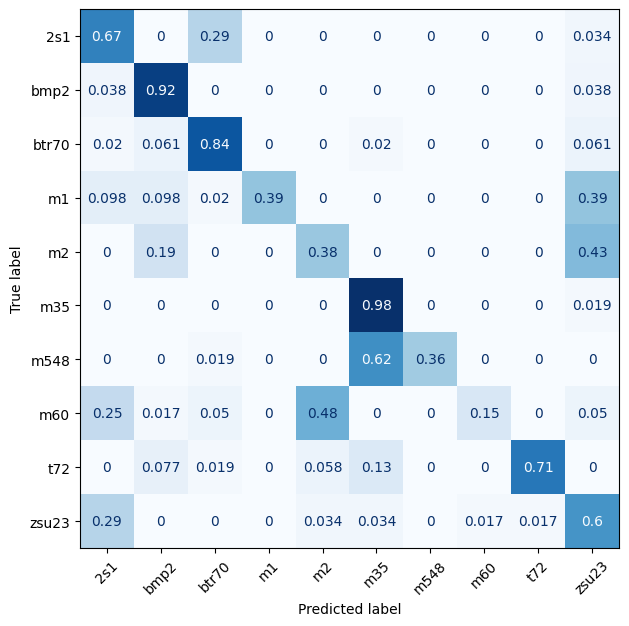

Evaluating shifted up of 10 units


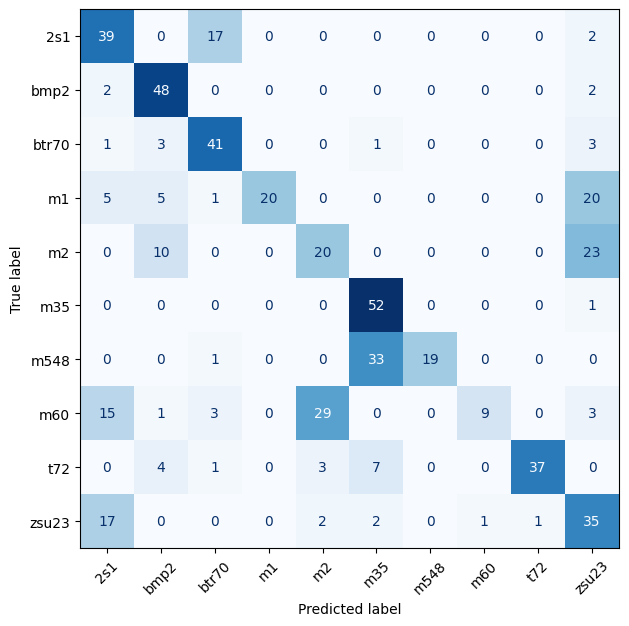

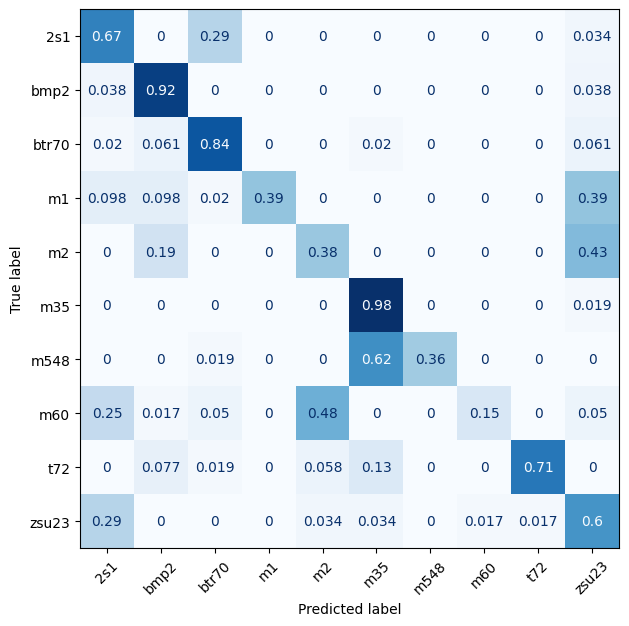

Evaluating shifted up of 15 units


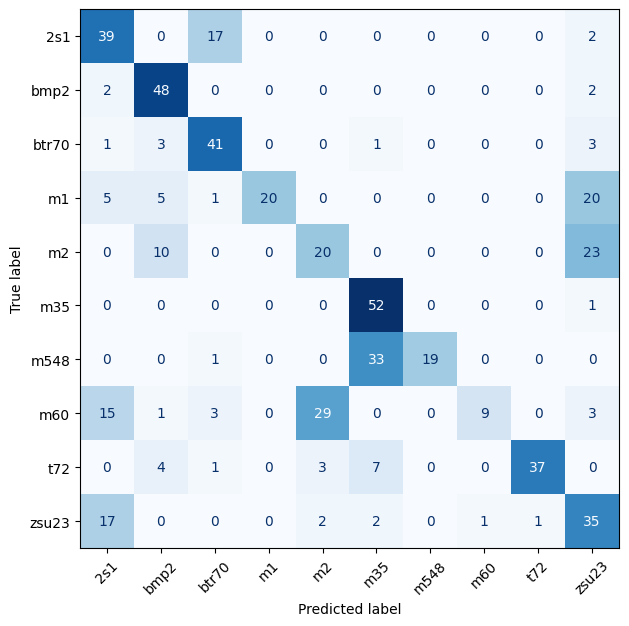

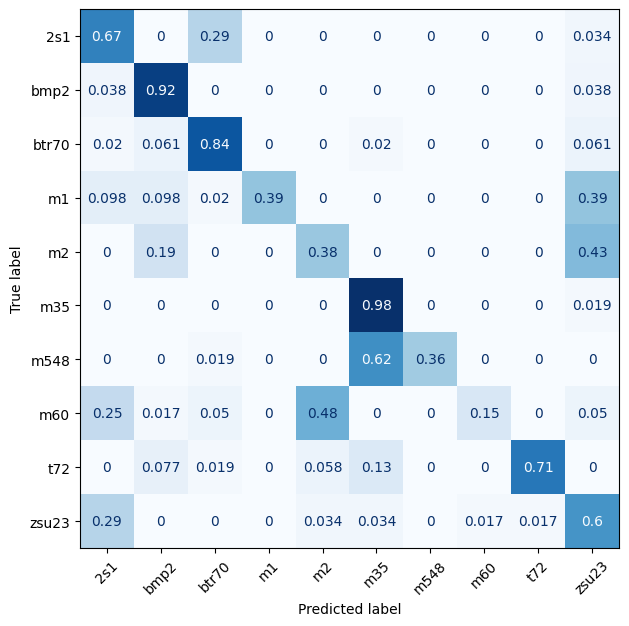

Evaluating shifted up of 20 units


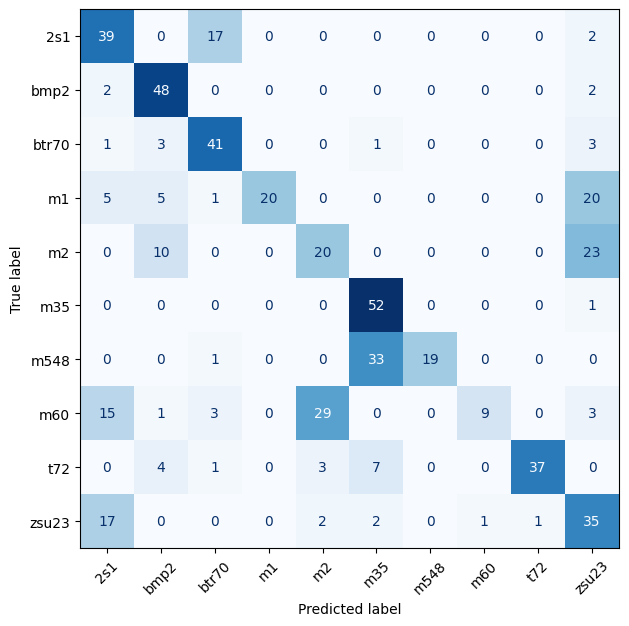

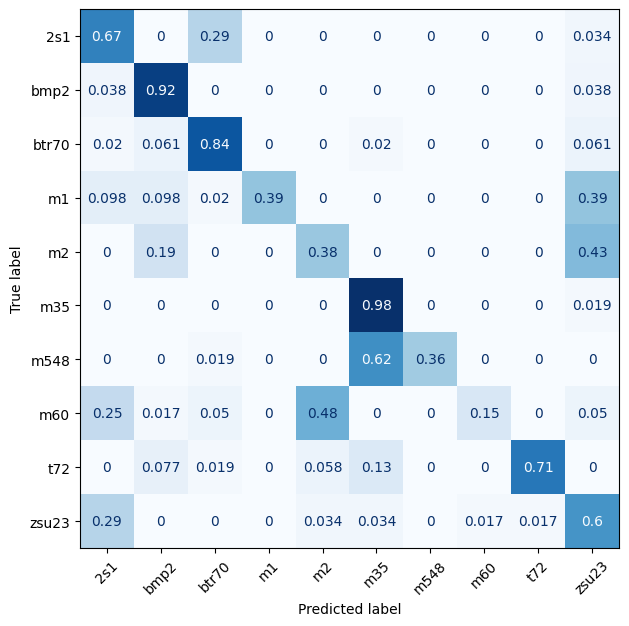

Evaluating shifted up of 25 units


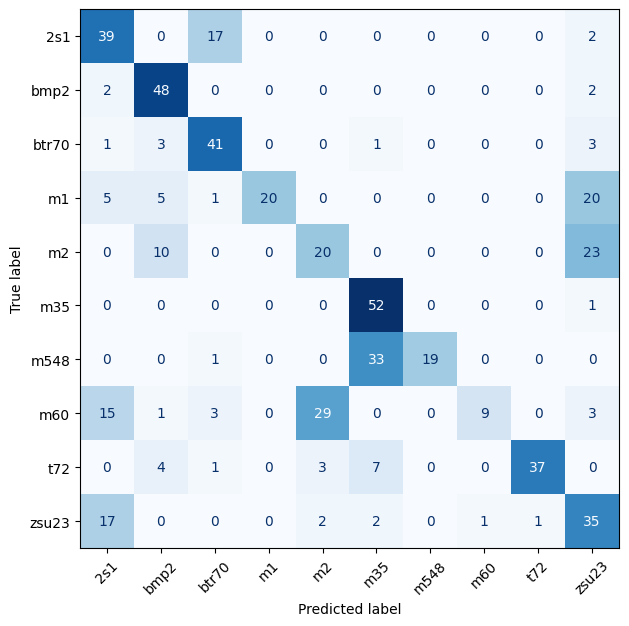

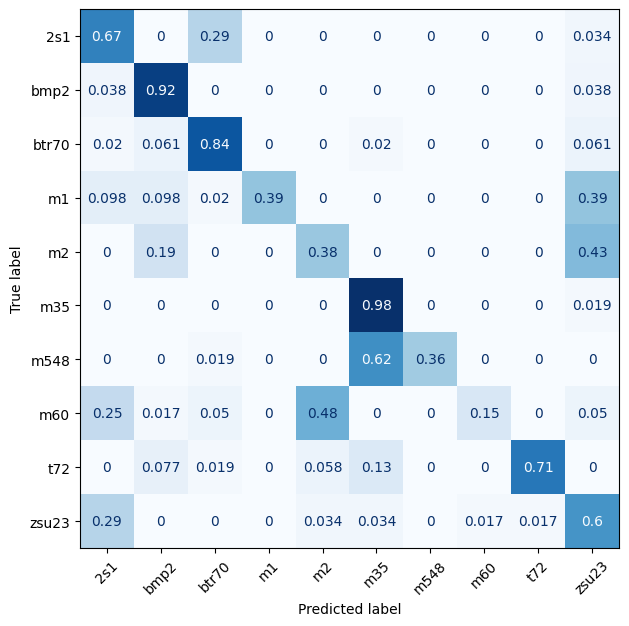

Evaluating shifted up of 30 units


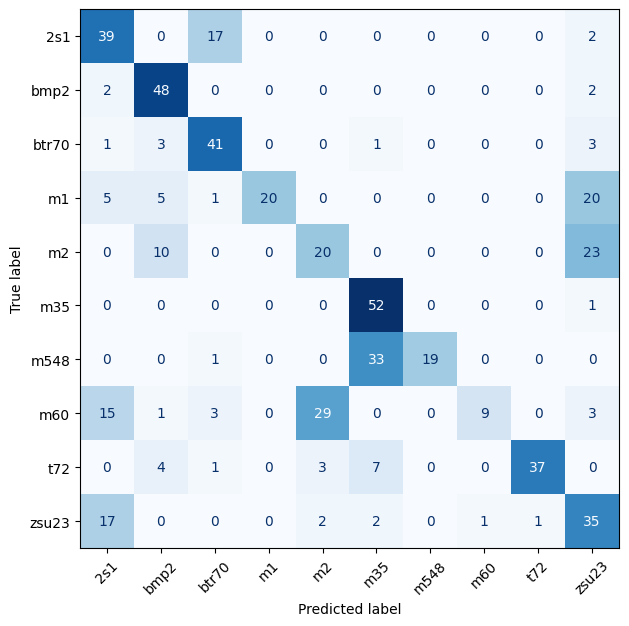

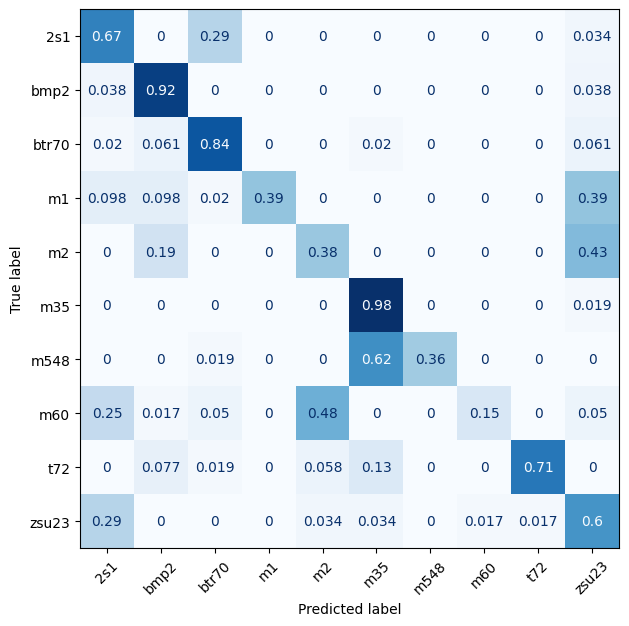

Evaluating shifted up of 35 units


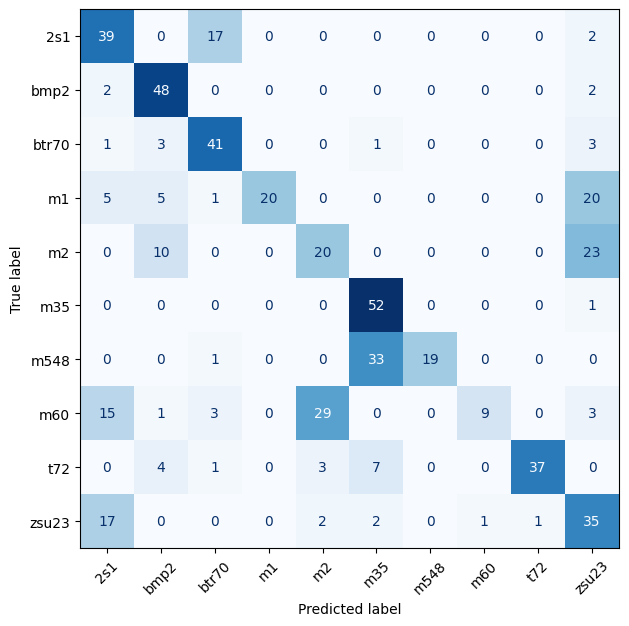

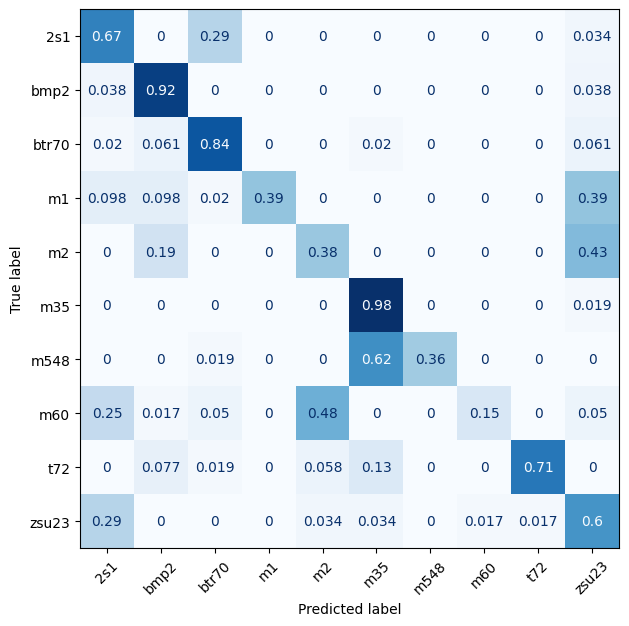

Evaluating shifted left of 5 units


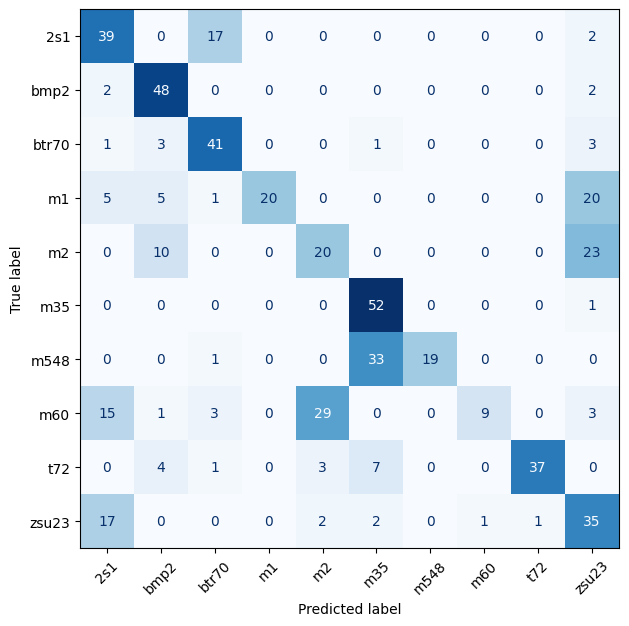

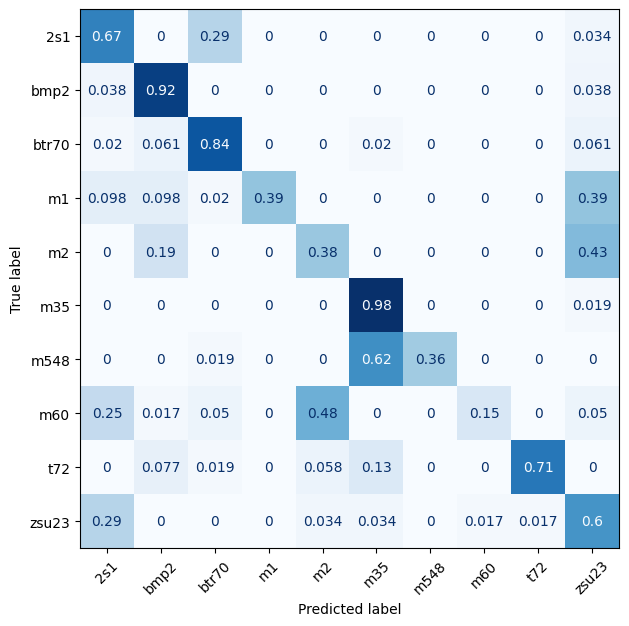

Evaluating shifted left of 10 units


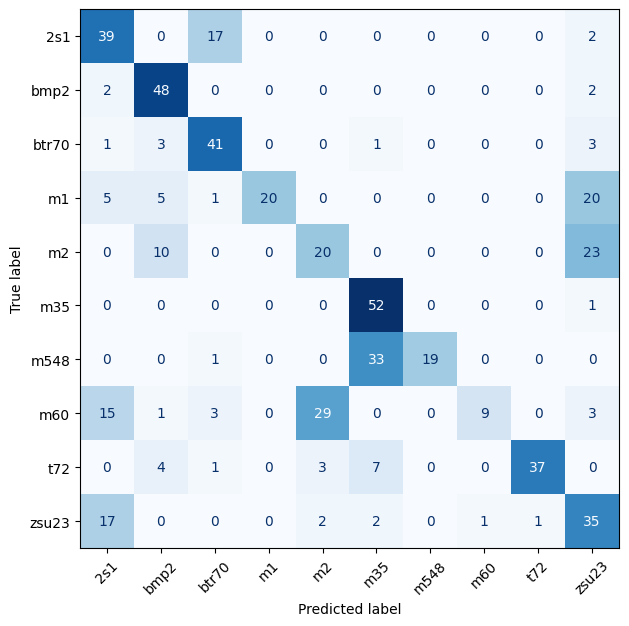

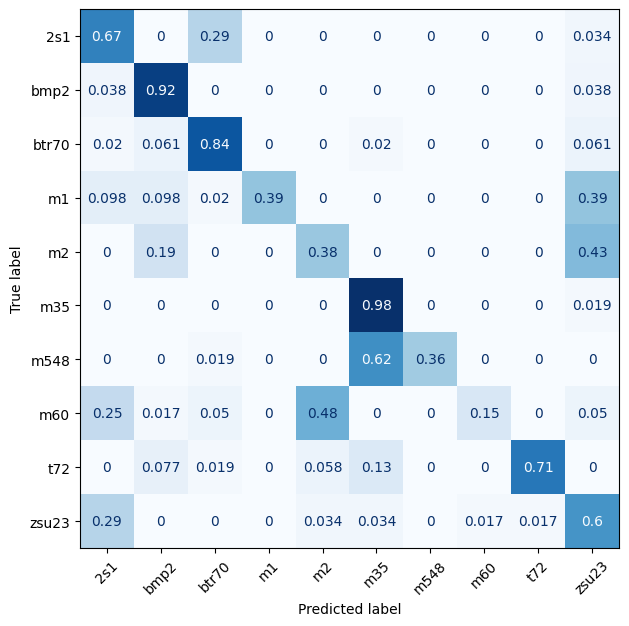

Evaluating shifted left of 15 units


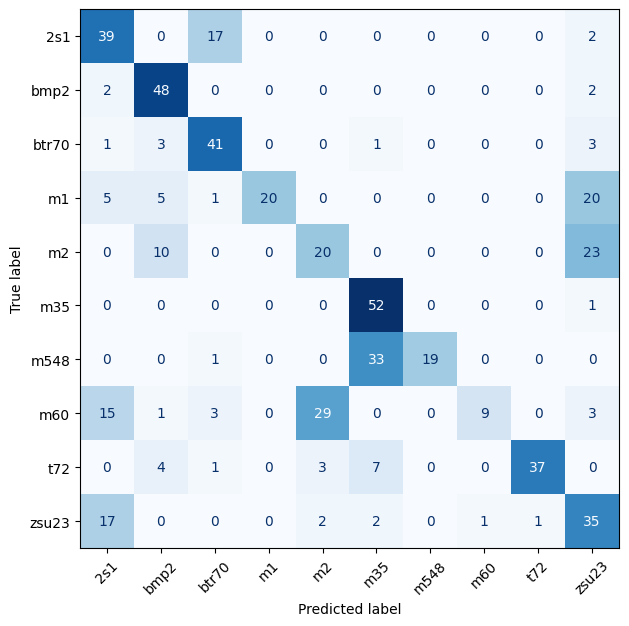

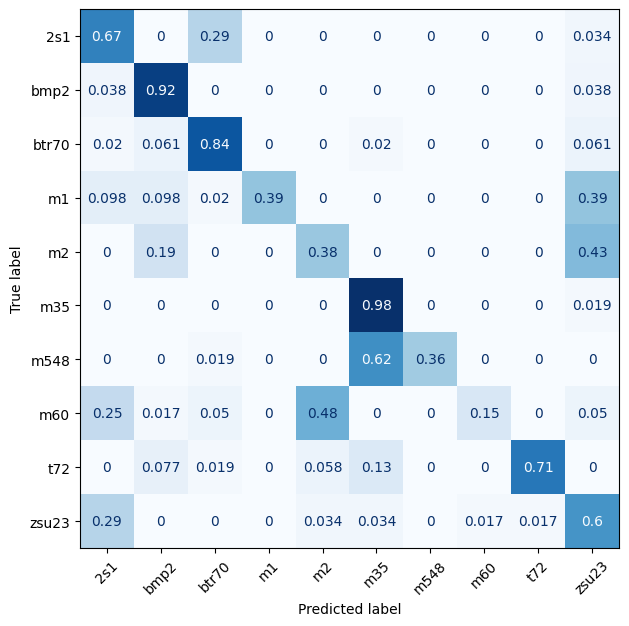

Evaluating shifted right of 5 units


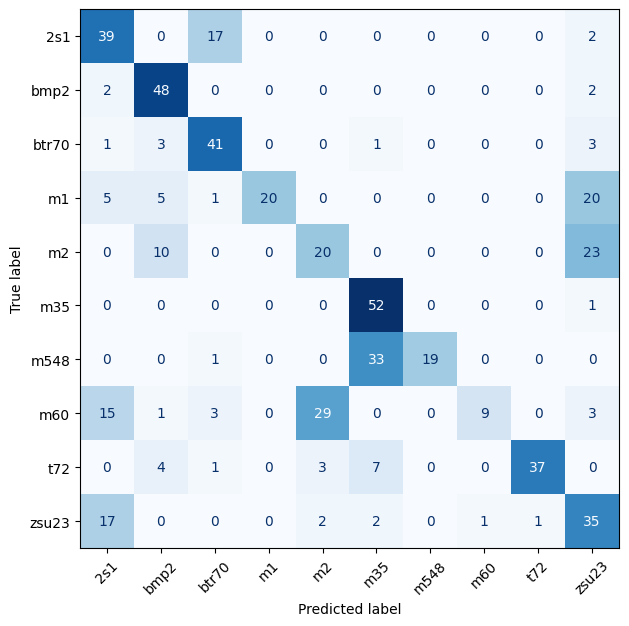

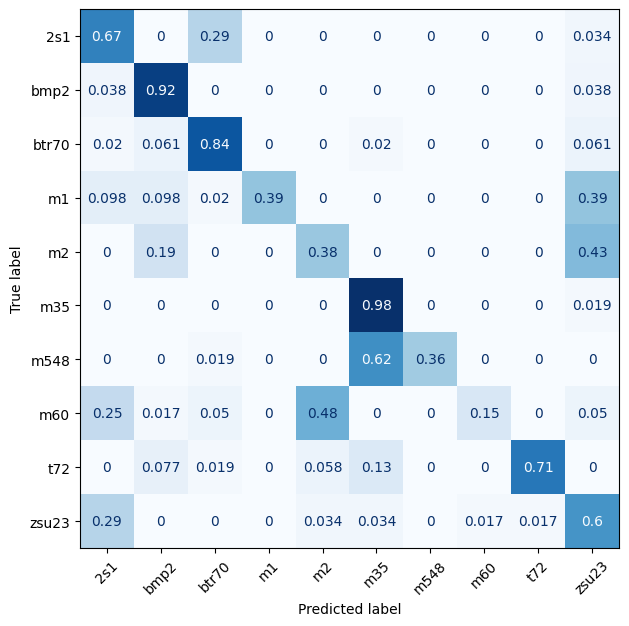

Evaluating shifted right of 10 units


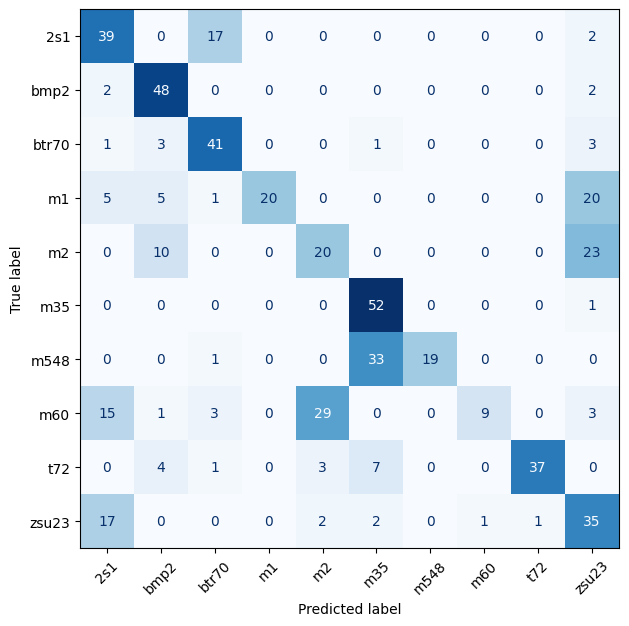

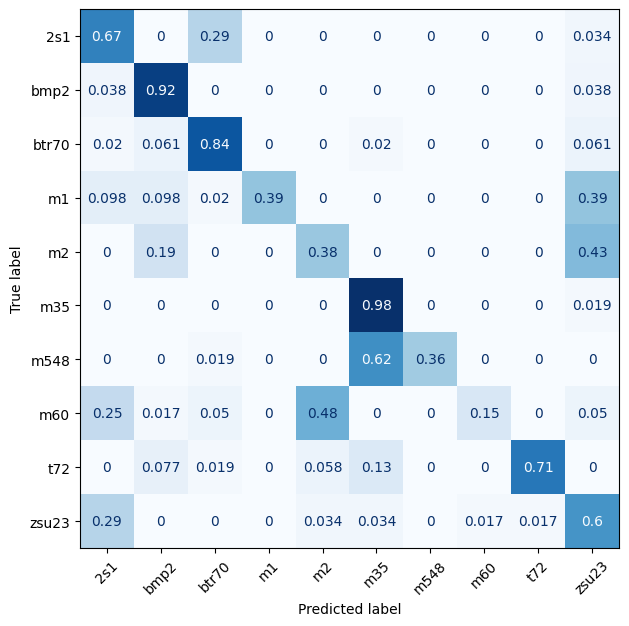

Evaluating shifted right of 15 units


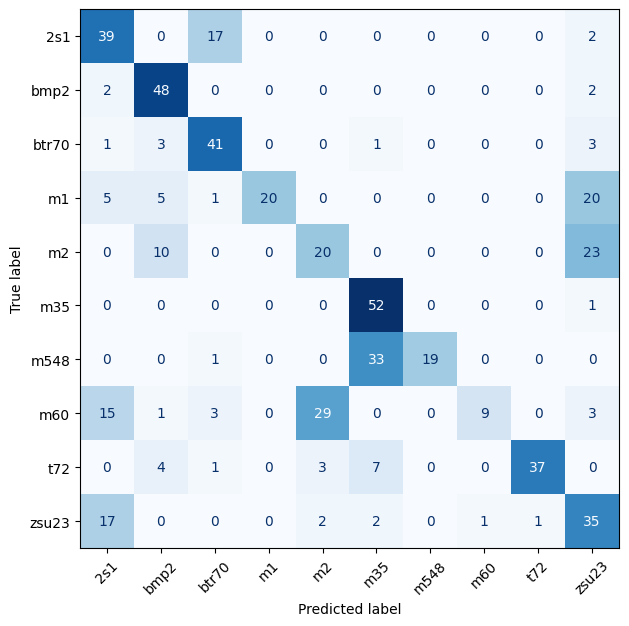

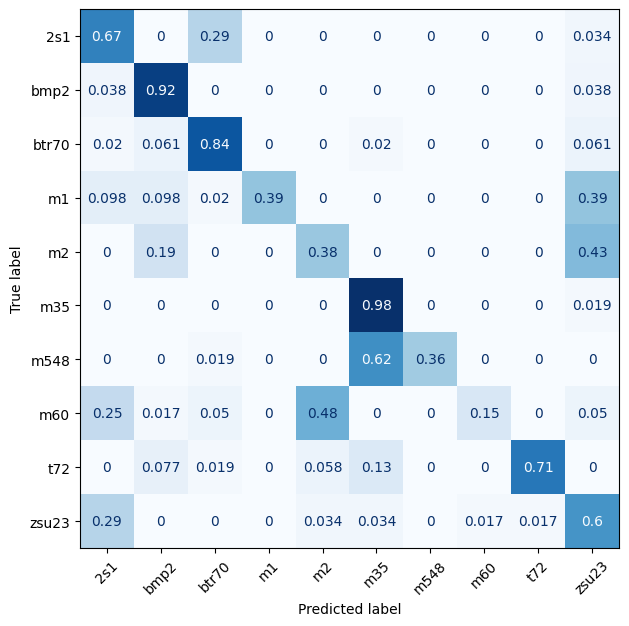

Evaluating shifted right of 20 units


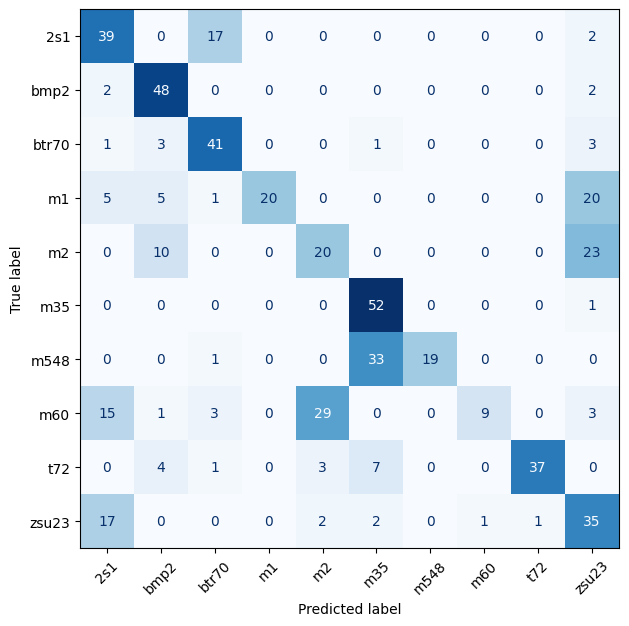

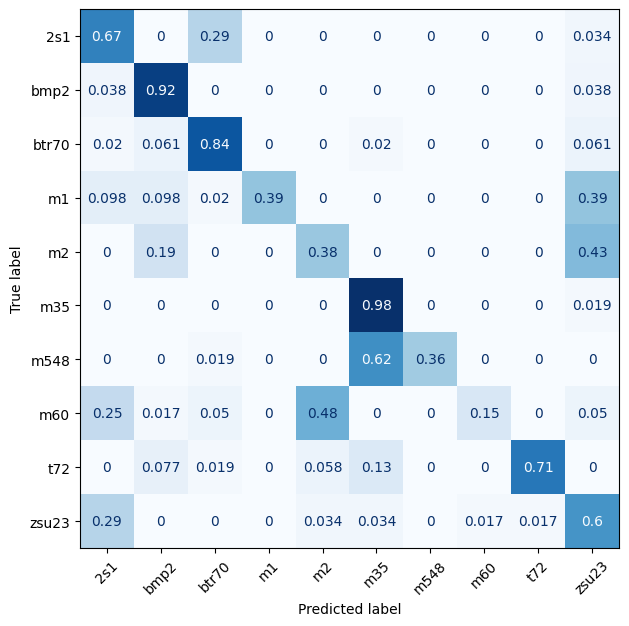

Evaluating shifted right of 25 units


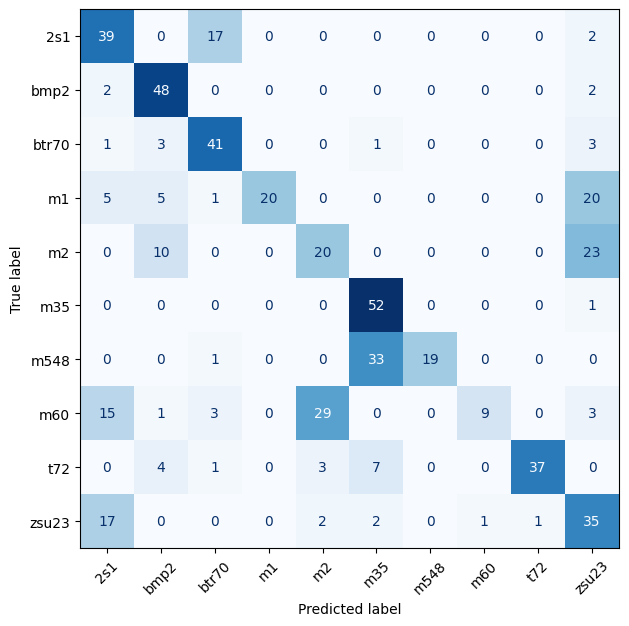

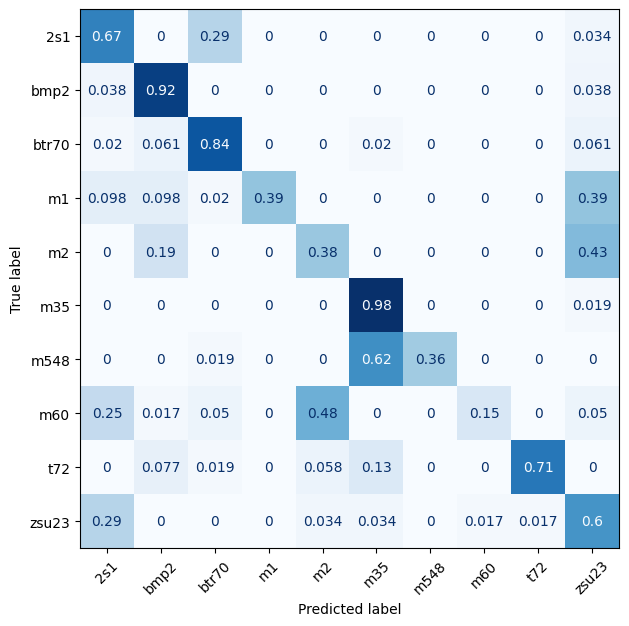

Evaluating shifted right of 30 units


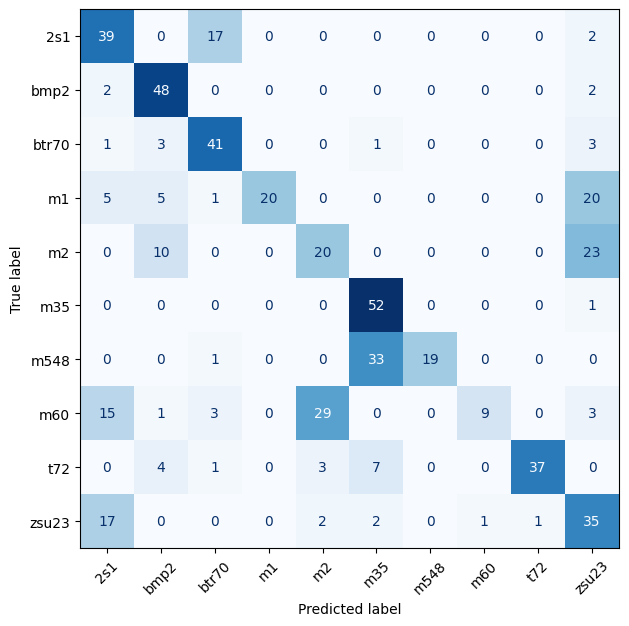

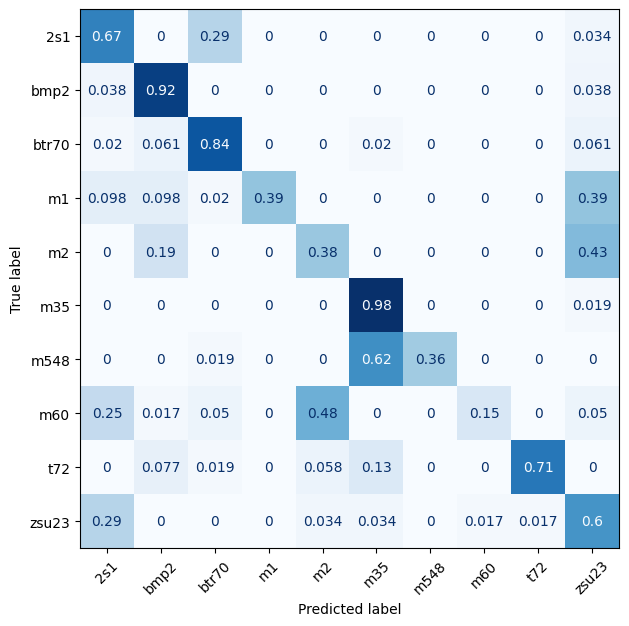

Evaluating shifted right of 35 units


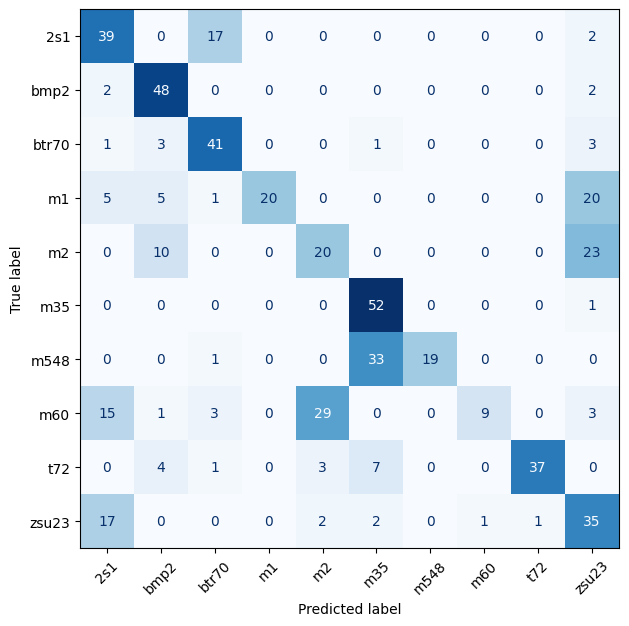

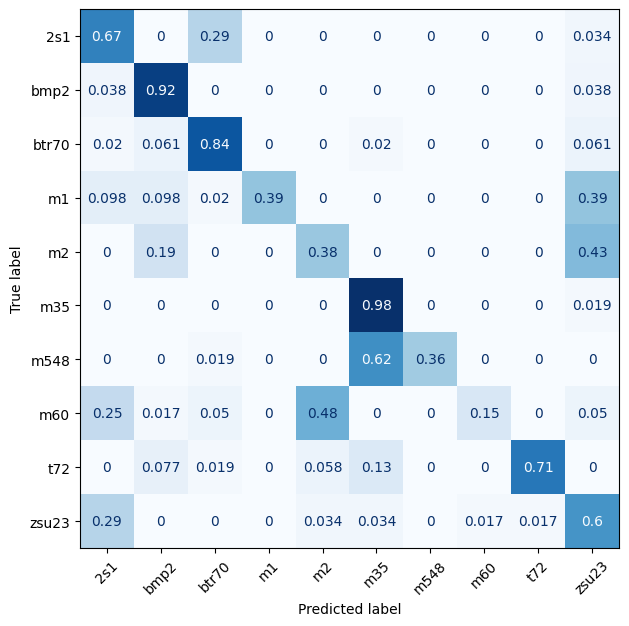

In [15]:
seed = 666
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

get_logits = get_logits_model('LPSLogitLayers')
pooling_layer = partial(PolyphaseInvariantDown2D, component_selection=LPS, get_logits=get_logits)
extras_model = {
        'logits_channels': {"maxpool": 8, "layer2": 16, "layer3": 32, "layer4": 64},
        'conv1_stride': False,
        'maxpool_zpad': False,
        'swap_conv_pool': True,
        'inc_conv1_support': True,
        'apply_maxpool': True,
        'ret_prob': True,
        'forward_pool_method': 'LPS',
    }
    
new_model = ResNet18Custom(
        input_shape=(3, 128, 128),
        num_classes=len(train_ds.class_to_idx),
        padding_mode='circular',
        pooling_layer=pooling_layer,
        extras_model=extras_model,
    )
new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Extras/LPD/target_only/gaussian/rn18_seed{seed}_b16_theirmodel.pth"),
        map_location=device
    ))

new_model = new_model.to(device)
new_model.eval()
    
for direction, (dataset_lst, units) in shifted_datasets_17.items():

    for k, ds in enumerate(dataset_lst):
        print(f"Evaluating {direction} of {units[k]} units")

        n_test = len(ds)
        labels_tensor = torch.zeros(n_test, dtype=torch.long, device=device)
        preds_tensor = torch.zeros(n_test, dtype=torch.long, device=device)
        
        idx = 0
        with torch.no_grad():
            for inputs, labels in DataLoader(ds, batch_size=32, shuffle=False, num_workers=8, pin_memory = True, persistent_workers=True):
                inputs = inputs.to(device)
                labels = labels.to(device)
        
                outputs = new_model(inputs)
                _, preds = torch.max(outputs, 1)
        
                bs = inputs.size(0)
                labels_tensor[idx:idx+bs] = labels
                preds_tensor[idx:idx+bs] = preds
                idx += bs
        
        _labels_all = labels_tensor.cpu().numpy()
        _preds_all = preds_tensor.cpu().numpy()
        
        cm = confusion_matrix(_labels_all, _preds_all)
        cm_cpu = cp.asnumpy(cm)
        disp = ConfusionMatrixDisplay(cm_cpu, display_labels=list(test_ds.class_to_idx.keys()))
        fig, ax = plt.subplots(figsize=(7, 7))
        disp.plot(ax=ax, cmap="Blues", colorbar=False)
        ax.tick_params(axis='x', rotation=45)
        plt.show()
        
        cm_norm = confusion_matrix(_labels_all, _preds_all, normalize='true')
        cm_norm_cpu = cp.asnumpy(cm_norm)
        disp = ConfusionMatrixDisplay(cm_norm_cpu, display_labels=list(test_ds.class_to_idx.keys()))
        fig, ax = plt.subplots(figsize=(7, 7))
        disp.plot(ax=ax, cmap="Blues", colorbar=False)
        ax.tick_params(axis='x', rotation=45)
        plt.show()